# Multi-Fish Cohort `[56h]` + `[56g]`

This notebook aggregates already processed fish and produces cohort-level versions of:
- `[56h]` (BPI + condensed ipsi/contra traces)
- `[56g]` (BPI vs activity diagnostics)

Configured fish for now:
- `L395_f11` (`owner='Danin'`)
- `L396_f01` (`owner='Matilde'`)
- `L396_f04` (`owner='Matilde'`)


In [46]:
# [cfg] Imports + cohort configuration
import os
import re
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.measure import regionprops_table
from IPython.display import display


def _default_nas_root():
    if os.name == "nt":
        base = Path(r"\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c")
        return base / "07_Data" if (base / "07_Data").exists() else base
    return Path("/Volumes/jlarsch/default/D2c/07_Data")


def _default_local_root():
    return Path("/Users/ddharmap/dataProcessing/2p_HCR/analysis/midThesis")


DATA_MODE = 'local'  # 'local' or 'nas'
NAS_ROOT = _default_nas_root()
LOCAL_ROOT = _default_local_root()
DATA_ROOT = LOCAL_ROOT if str(DATA_MODE).strip().lower() == 'local' else NAS_ROOT
MATCHING_METADATA_CSV_OVERRIDE = None
MATCHING_METADATA_CSV = Path(MATCHING_METADATA_CSV_OVERRIDE) if MATCHING_METADATA_CSV_OVERRIDE else (
    DATA_ROOT / 'matchingMetadata.csv' if str(DATA_MODE).strip().lower() == 'local' else NAS_ROOT / 'Danin' / 'matchingMetadata.csv'
)

FISH_SPECS = [
    {"owner": "Matilde", "fish_id": "L395_f11"},
    {"owner": "Matilde", "fish_id": "L396_f01"},
    {"owner": "Matilde", "fish_id": "L396_f03"},
    {"owner": "Matilde", "fish_id": "L396_f04"},
]

# Core timing/trace parameters (aligned with single-fish [56h]).
WINDOW_PRE_SEC = 20.0
WINDOW_POST_SEC = 50.0
STIM_ONSET_DELAY_SEC = 10.0
WINDOW_EDGE_POLICY = 'pad_nan'
MIN_VALID_POINTS_PER_SEG = 1
BPI_EDGE_POLICY = 'pad_nan'
BPI_MIN_VALID_FRAC = 0.5
BPI_MIN_TRIALS_PER_CLASS = 3
BPI_DENOM_EPS = 1e-6
ZSCORE_MIN_BASELINE_POINTS = 200
ZSCORE_MIN_BASELINE_STD = 1e-6
STIM_TIME_SCALE = 1.0

MEASURE_START_BLOCK = 1
MEASURE_START_EVENT = 'start'
REMOVE_INTERBLOCK_GAPS = True

# Cohort plotting parameters.
MIN_SEGMENTS = 3
MIN_CELLS = 1
MAX_GENES = 12
USE_SEM = True
COHORT_TRACE_DT = None  # seconds; None -> infer from first fish fps

# Optional high-confidence filter if low-confidence columns are present in conf_to_func_pairs.csv.
USE_HIGH_CONF_ONLY = True
LOW_CONF_COLUMNS = [
    '_is_low_conf_q95',
    '_is_low_conf_match_any_globalR50',
    'is_low_confidence_segmentation',
]

DEFAULT_GENE_ORDER = ['sst1.1', 'sst1.2', 'npy', 'tac3b', 'pth2', 'cfos', 'cort']
DEFAULT_GENE_COLORS = {
    'sst1.1': '#d62728',
    'sst1.2': '#d61ad2',
    'npy': '#1f9d55',
    'tac3b': '#ffd400',
    'pth2': '#00bcd4',
    'cfos': '#ff7f0e',
    'cort': '#8c564b',
}
GENE_ORDER = list(DEFAULT_GENE_ORDER)
GENE_COLORS = dict(DEFAULT_GENE_COLORS)

PANEL_GRID = [["contra_LB", "contra_LC"], ["ipsi_LB", "ipsi_LC"]]
PLOT_ORDER = [p for row in PANEL_GRID for p in row]
PLOT_TITLES = {
    "contra_LB": "Contra × bout-like",
    "contra_LC": "Contra × continuous",
    "ipsi_LB": "Ipsi × bout-like",
    "ipsi_LC": "Ipsi × continuous",
}

COHORT_OUTDIR_OVERRIDE = None
COHORT_OUTDIR_DEFAULT = (
    DATA_ROOT / 'cohort_outputs' / 'multi_fish_56h_56g'
    if str(DATA_MODE).strip().lower() == 'local'
    else Path.cwd() / 'cohort_outputs' / 'multi_fish_56h_56g'
)
COHORT_OUTDIR = Path(COHORT_OUTDIR_OVERRIDE) if COHORT_OUTDIR_OVERRIDE else Path(COHORT_OUTDIR_DEFAULT)
COHORT_OUTDIR.mkdir(parents=True, exist_ok=True)


def cohort_cache_paths(outdir):
    outdir = Path(outdir)
    return {
        "fish_summary_csv": outdir / "cohort_fish_processing_summary.csv",
        "stim_summary_csv": outdir / "cohort_stim_ipsi_contra_summary.csv",
        "bpi_trials_csv": outdir / "cohort_bpi_trials.csv",
        "bpi_cells_csv": outdir / "cohort_bpi_cells.csv",
        "trace_cache_pkl": outdir / "cohort_trace_cache.pkl",
    }


def count_trace_genes(results, plot_order, *, nested=False):
    genes = set()
    if not isinstance(results, dict):
        return 0

    if nested:
        for panel_map in results.values():
            if not isinstance(panel_map, dict):
                continue
            for panel in plot_order:
                gene_map = (panel_map.get(panel, {}) or {})
                if isinstance(gene_map, dict):
                    genes.update(str(g) for g in gene_map.keys())
    else:
        for panel in plot_order:
            gene_map = (results.get(panel, {}) or {})
            if isinstance(gene_map, dict):
                genes.update(str(g) for g in gene_map.keys())

    return len(genes)


def save_cohort_outputs_to_disk(
    outdir,
    *,
    cohort_fish_summary_df=None,
    cohort_stim_summary_df=None,
    cohort_bpi_trials_df=None,
    cohort_bpi_cells_df=None,
    cohort_tvec=None,
    cohort_results_stim_ipsi_contra=None,
    cohort_results_stim_ipsi_contra_by_fish=None,
    cohort_results_stim_ipsi_contra_per_cell_by_fish=None,
    cohort_mode_durations=None,
    cohort_mode_event_counts=None,
    verbose=True,
):
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)
    p = cohort_cache_paths(outdir)

    if isinstance(cohort_fish_summary_df, pd.DataFrame) and (not cohort_fish_summary_df.empty):
        cohort_fish_summary_df.to_csv(p["fish_summary_csv"], index=False)
    if isinstance(cohort_stim_summary_df, pd.DataFrame) and (not cohort_stim_summary_df.empty):
        cohort_stim_summary_df.to_csv(p["stim_summary_csv"], index=False)
    if isinstance(cohort_bpi_trials_df, pd.DataFrame) and (not cohort_bpi_trials_df.empty):
        cohort_bpi_trials_df.to_csv(p["bpi_trials_csv"], index=False)
    if isinstance(cohort_bpi_cells_df, pd.DataFrame) and (not cohort_bpi_cells_df.empty):
        cohort_bpi_cells_df.to_csv(p["bpi_cells_csv"], index=False)

    trace_payload = {
        "cohort_tvec": np.asarray(cohort_tvec, dtype=np.float32) if cohort_tvec is not None else None,
        "cohort_results_stim_ipsi_contra": cohort_results_stim_ipsi_contra,
        "cohort_results_stim_ipsi_contra_by_fish": cohort_results_stim_ipsi_contra_by_fish,
        "cohort_results_stim_ipsi_contra_per_cell_by_fish": cohort_results_stim_ipsi_contra_per_cell_by_fish,
        "cohort_mode_durations": cohort_mode_durations,
        "cohort_mode_event_counts": cohort_mode_event_counts,
    }
    trace_gene_count = count_trace_genes(cohort_results_stim_ipsi_contra, PLOT_ORDER)
    trace_gene_count_by_fish = count_trace_genes(cohort_results_stim_ipsi_contra_by_fish, PLOT_ORDER, nested=True)
    if (
        trace_payload["cohort_tvec"] is not None
        and trace_payload["cohort_results_stim_ipsi_contra"] is not None
        and trace_gene_count > 0
        and trace_gene_count_by_fish > 0
    ):
        with open(p["trace_cache_pkl"], "wb") as f:
            pickle.dump(trace_payload, f, protocol=pickle.HIGHEST_PROTOCOL)
    elif p["trace_cache_pkl"].exists():
        p["trace_cache_pkl"].unlink()

    if verbose:
        print(f"[cache] saved cohort outputs in {outdir}")


def load_cohort_outputs_from_disk(
    outdir,
    *,
    load_tables=True,
    load_trace_cache=True,
    verbose=True,
):
    outdir = Path(outdir)
    p = cohort_cache_paths(outdir)
    loaded = []
    state = {}

    if load_tables:
        table_specs = [
            ("cohort_fish_summary_df", p["fish_summary_csv"]),
            ("cohort_stim_summary_df", p["stim_summary_csv"]),
            ("cohort_bpi_trials_df", p["bpi_trials_csv"]),
            ("cohort_bpi_cells_df", p["bpi_cells_csv"]),
        ]
        for key, csv_path in table_specs:
            if csv_path.exists():
                try:
                    state[key] = pd.read_csv(csv_path)
                    loaded.append(key)
                except Exception as e:
                    if verbose:
                        print(f"[cache] failed loading {csv_path.name}: {e}")

    if load_trace_cache and p["trace_cache_pkl"].exists():
        try:
            with open(p["trace_cache_pkl"], "rb") as f:
                payload = pickle.load(f)
            for key in [
                "cohort_tvec",
                "cohort_results_stim_ipsi_contra",
                "cohort_results_stim_ipsi_contra_by_fish",
                "cohort_results_stim_ipsi_contra_per_cell_by_fish",
                "cohort_mode_durations",
                "cohort_mode_event_counts",
            ]:
                if key in payload:
                    state[key] = payload.get(key)
                    loaded.append(key)
        except Exception as e:
            if verbose:
                print(f"[cache] failed loading {p['trace_cache_pkl'].name}: {e}")

    if verbose:
        if loaded:
            print(f"[cache] loaded: {', '.join(sorted(set(loaded)))}")
        else:
            print(f"[cache] no cached cohort outputs loaded from {outdir}")

    return state

print(f"[cfg] DATA_MODE={DATA_MODE}")
print(f"[cfg] DATA_ROOT={DATA_ROOT}")
print(f"[cfg] MATCHING_METADATA_CSV={MATCHING_METADATA_CSV}")
print(f"[cfg] fishes={[(d['owner'], d['fish_id']) for d in FISH_SPECS]}")
print(f"[cfg] COHORT_OUTDIR={COHORT_OUTDIR}")




[cfg] DATA_MODE=local
[cfg] DATA_ROOT=/Users/ddharmap/dataProcessing/2p_HCR/analysis/midThesis
[cfg] MATCHING_METADATA_CSV=/Users/ddharmap/dataProcessing/2p_HCR/analysis/midThesis/matchingMetadata.csv
[cfg] fishes=[('Matilde', 'L395_f11'), ('Matilde', 'L396_f01'), ('Matilde', 'L396_f03'), ('Matilde', 'L396_f04')]
[cfg] COHORT_OUTDIR=/Users/ddharmap/dataProcessing/2p_HCR/analysis/midThesis/cohort_outputs/multi_fish_56h_56g


In [47]:
# [helpers] File discovery, parsing, side-assignment, and trace utilities
import pathlib


def owner_root(data_root, owner):
    base = Path(data_root) / str(owner)
    mic = base / "Microscopy"
    return mic if mic.exists() else base


def resolve_fish_dir(data_root, owner, fish_id, data_mode='nas'):
    root = Path(data_root)
    fish_id = str(fish_id)
    owner = str(owner)
    if str(data_mode).strip().lower() == 'local':
        candidates = [
            root / fish_id,
            root / owner / fish_id,
            root / owner / 'Microscopy' / fish_id,
        ]
        for cand in candidates:
            if cand.exists():
                return cand
        return root / fish_id
    return owner_root(root, owner) / fish_id


def fish_paths(data_root, owner, fish_id, data_mode='nas'):
    fish_dir = resolve_fish_dir(data_root, owner, fish_id, data_mode=data_mode)
    analysis_dir = fish_dir / "03_analysis"
    func_dir = analysis_dir / "functional"
    out_reg = func_dir / "registration"
    suite2p_root = func_dir / "suite2P"
    conf_csv = out_reg / "conf_to_func_pairs.csv"
    midline_json = out_reg / "midline_params_func_ref.json"
    metadata_dir = fish_dir / "01_raw" / "2p" / "metadata"
    return {
        "fish_dir": fish_dir,
        "analysis_dir": analysis_dir,
        "func_dir": func_dir,
        "out_reg": out_reg,
        "suite2p_root": suite2p_root,
        "conf_csv": conf_csv,
        "midline_json": midline_json,
        "metadata_dir": metadata_dir,
    }


def load_matching_metadata(path):
    p = Path(path)
    if not p.exists():
        return None
    try:
        return pd.read_csv(p)
    except Exception:
        return None


_MD_CACHE = load_matching_metadata(MATCHING_METADATA_CSV)


def get_polarity(fish_id, md_df=None):
    if md_df is None:
        md_df = _MD_CACHE
    if md_df is None or md_df.empty or "fish_id" not in md_df.columns:
        return None
    row = md_df.loc[md_df["fish_id"].astype(str) == str(fish_id)]
    if row.empty:
        return None
    pol = str(row.iloc[0].get("polarity", "")).strip().lower()
    if pol in {"north", "south"}:
        return pol
    return None


def _block_key(code):
    m = re.match(r"^B(\d+)$", str(code))
    return int(m.group(1)) if m else 10**9


def find_experiment_log(metadata_dir, fish_id):
    base = Path(metadata_dir)
    if not base.exists():
        return None
    pats = [f"*{fish_id}*experiment_log*.csv", "*experiment_log*.csv"]
    hits = []
    for pat in pats:
        hits.extend(sorted(base.glob(pat)))
    if not hits:
        return None
    hits = sorted(set(hits), key=lambda p: p.stat().st_mtime)
    return hits[-1]


def load_events_df(csv_path, time_scale=1.0):
    df = pd.read_csv(csv_path)
    if df.empty:
        raise ValueError("experiment log is empty")
    cols = {c: c.strip().lower() for c in df.columns}
    df = df.rename(columns=cols)

    event_cols = [c for c in df.columns if "event" in c]
    time_cols = [c for c in df.columns if ("timestamp" in c) or (c == "time")]

    if "event" in df.columns:
        event_col = "event"
    elif event_cols:
        event_col = event_cols[0]
    else:
        raise ValueError(f"Could not infer event column from {list(df.columns)}")

    if "timestamp" in df.columns:
        time_col = "timestamp"
    elif "time" in df.columns:
        time_col = "time"
    elif time_cols:
        time_col = time_cols[0]
    else:
        raise ValueError(f"Could not infer time column from {list(df.columns)}")

    out = df[[event_col, time_col]].rename(columns={event_col: "event", time_col: "time"})
    out["event"] = out["event"].astype(str).str.strip()
    out["time"] = pd.to_numeric(out["time"], errors="coerce") * float(time_scale)
    out = out.dropna(subset=["event", "time"]).sort_values("time").reset_index(drop=True)
    return out


def build_stim_table(df_evt, measure_start_block=1, measure_start_event="start", remove_interblock_gaps=True):
    evt = df_evt.copy()

    if measure_start_block is not None:
        if isinstance(measure_start_block, str):
            block_label = measure_start_block
        else:
            block_label = f"B{int(measure_start_block)}"
        start_event = f"{block_label}_{measure_start_event}"
        start_match = evt.loc[evt["event"] == start_event, "time"]
        if len(start_match):
            t0 = float(start_match.iloc[0])
        else:
            block_rows = evt[evt["event"].str.startswith(f"{block_label}_")]
            t0 = float(block_rows["time"].min()) if not block_rows.empty else None
        if t0 is not None:
            evt["time"] = evt["time"] - t0
            evt = evt[evt["time"] >= 0].reset_index(drop=True)

    block_codes = []
    for ev in evt["event"]:
        m = re.match(r"^(B\d+)_", ev)
        if m:
            block_codes.append(m.group(1))
    block_codes = sorted(set(block_codes), key=_block_key)

    blocks = []
    for b in block_codes:
        block_events = evt[evt["event"].str.startswith(f"{b}_")]
        if block_events.empty:
            continue
        bstart = None
        bend = None
        s = block_events.loc[block_events["event"] == f"{b}_start", "time"]
        if len(s):
            bstart = float(s.iloc[0])
        e = block_events.loc[block_events["event"] == f"{b}_end", "time"]
        if len(e):
            bend = float(e.iloc[0])
        if bstart is None:
            bstart = float(block_events["time"].min())
        ib = block_events.loc[block_events["event"] == f"{b}_interblock_pause", "time"]
        ib_time = float(ib.iloc[0]) if len(ib) else None
        if bend is None:
            bend = ib_time
        elif ib_time is not None:
            bend = ib_time
        if bend is None:
            bend = float(block_events["time"].max())
        blocks.append({"block": b, "start": bstart, "end": bend})

    if remove_interblock_gaps and blocks:
        blocks = sorted(blocks, key=lambda d: d["start"])
        shift_map = {}
        shift = 0.0
        prev_end = None
        for blk in blocks:
            orig_start = float(blk["start"])
            orig_end = float(blk["end"])
            if prev_end is not None:
                gap = max(0.0, orig_start - prev_end)
                shift += gap
            shift_map[blk["block"]] = shift
            blk["start"] = orig_start - shift
            blk["end"] = orig_end - shift
            prev_end = orig_end

        def _shift_evt_time(row):
            m = re.match(r"^(B\d+)_", str(row["event"]))
            if not m:
                return float(row["time"])
            return float(row["time"]) - float(shift_map.get(m.group(1), 0.0))

        evt["time"] = evt.apply(_shift_evt_time, axis=1)
        evt = evt.sort_values("time").reset_index(drop=True)

    stims = []
    for _, row in evt.iterrows():
        m = re.match(r"^(B\d+)_stim(\d+)_(.+)$", str(row["event"]))
        if not m:
            continue
        block = m.group(1)
        stim_idx = int(m.group(2))
        stim_type = str(m.group(3))
        t0 = float(row["time"])

        end_time = None
        post_name = f"{block}_poststim{stim_idx}_pause"
        match = evt.loc[evt["event"] == post_name, "time"]
        if len(match):
            end_time = float(match.iloc[0])
        if end_time is None:
            after = evt[(evt["time"] > t0) & evt["event"].str.startswith(f"{block}_")].sort_values("time")
            end_time = float(after["time"].iloc[0]) if not after.empty else t0 + 10.0

        stims.append({
            "block": block,
            "stim_idx": stim_idx,
            "type": stim_type,
            "start": t0,
            "end": end_time,
            "duration": float(end_time - t0),
        })

    return evt, pd.DataFrame(stims), blocks


def _load_ops_npy(path):
    try:
        return np.load(path, allow_pickle=True).item()
    except NotImplementedError:
        _orig_win = pathlib.WindowsPath
        _orig_pure = pathlib.PureWindowsPath
        pathlib.WindowsPath = pathlib.PosixPath
        pathlib.PureWindowsPath = pathlib.PurePosixPath
        try:
            return np.load(path, allow_pickle=True).item()
        finally:
            pathlib.WindowsPath = _orig_win
            pathlib.PureWindowsPath = _orig_pure


def _find_suite2p_file(plane_dir, key):
    p = Path(plane_dir) / f"{key}.npy"
    if p.exists():
        return p
    hits = sorted(Path(plane_dir).glob(f"*_{key}.npy"))
    return hits[0] if hits else None


def _plane_num_from_name(name):
    m = re.search(r"plane(\d+)", str(name))
    return int(m.group(1)) if m else None


def apply_func_orientation(arr, polarity):
    if arr is None or getattr(arr, "ndim", 0) < 2:
        return arr
    out = arr
    if str(polarity).lower() == "north":
        out = out[..., ::-1, ::-1]
    out = out[..., ::-1]
    return out


def build_labels_from_stat(stat, iscell, ops):
    Ly = int(ops.get("Ly", 0))
    Lx = int(ops.get("Lx", 0))
    labels = np.zeros((Ly, Lx), dtype=np.uint32)
    keep = np.asarray(iscell)[:, 0].astype(bool)
    idxs = np.where(keep)[0]
    for roi_idx in idxs:
        s = stat[roi_idx]
        if isinstance(s, dict):
            ypix = np.asarray(s.get("ypix", []), dtype=np.int64)
            xpix = np.asarray(s.get("xpix", []), dtype=np.int64)
            overlap = s.get("overlap", None)
        else:
            ypix = np.asarray(s["ypix"], dtype=np.int64)
            xpix = np.asarray(s["xpix"], dtype=np.int64)
            dtype_names = getattr(getattr(s, "dtype", None), "names", None)
            overlap = s["overlap"] if dtype_names and "overlap" in dtype_names else None
        if overlap is not None:
            ok = ~np.asarray(overlap, dtype=bool)
            ypix = ypix[ok]
            xpix = xpix[ok]
        if ypix.size and xpix.size:
            labels[ypix, xpix] = roi_idx + 1
    return labels, keep


def load_suite2p_map(suite2p_root, polarity, dfof_baseline_pct=10.0, dfof_eps=1e-6):
    root = Path(suite2p_root)
    plane_dirs = [p for p in root.glob("plane*") if p.is_dir()]
    plane_dirs = sorted(plane_dirs, key=lambda p: (_plane_num_from_name(p.name) if _plane_num_from_name(p.name) is not None else p.name))

    s2p_map = {}
    roi_rows = []
    fps_vals = []

    for pd_i, plane_dir in enumerate(plane_dirs):
        plane_num = _plane_num_from_name(plane_dir.name)
        if plane_num is None:
            plane_num = int(pd_i)

        paths = {k: _find_suite2p_file(plane_dir, k) for k in ("F", "Fneu", "spks", "stat", "ops", "iscell")}
        if any(v is None for v in paths.values()):
            continue

        F = np.load(paths["F"], allow_pickle=True)
        Fneu = np.load(paths["Fneu"], allow_pickle=True)
        spks = np.load(paths["spks"], allow_pickle=True)
        stat = np.load(paths["stat"], allow_pickle=True)
        ops = _load_ops_npy(paths["ops"])
        iscell = np.load(paths["iscell"], allow_pickle=True)

        labels, keep = build_labels_from_stat(stat, iscell, ops)
        labels = apply_func_orientation(labels, polarity)

        try:
            props = regionprops_table(labels.astype(np.int32, copy=False), properties=("label", "centroid"))
            rdf = pd.DataFrame(props)
            if not rdf.empty:
                rdf = rdf[rdf["label"] != 0].copy()
                if not rdf.empty:
                    rdf = rdf.rename(columns={"label": "func_label", "centroid-0": "y", "centroid-1": "x"})
                    rdf["plane"] = int(plane_num)
                    roi_rows.append(rdf[["plane", "func_label", "x", "y"]])
        except Exception:
            pass

        F_raw = np.asarray(F, dtype=np.float32)
        F0 = np.percentile(F_raw, float(dfof_baseline_pct), axis=1, keepdims=True)
        dff = (F_raw - F0) / (F0 + float(dfof_eps))

        fs = ops.get("fs", None)
        if fs is not None:
            try:
                fps_vals.append(float(fs))
            except Exception:
                pass

        s2p_map[int(plane_num)] = {
            "plane_num": int(plane_num),
            "plane_dir": plane_dir,
            "labels": labels,
            "iscell_keep": keep,
            "F": F,
            "Fneu": Fneu,
            "spks": spks,
            "stat": stat,
            "ops": ops,
            "iscell": iscell,
            "dff": dff,
            "flip_x": False,
            "func_orient": "rot180+flipX" if str(polarity).lower() == "north" else "flipX",
        }

    roi_df = pd.concat(roi_rows, ignore_index=True) if roi_rows else pd.DataFrame(columns=["plane", "func_label", "x", "y"])

    fps = None
    if fps_vals:
        fps = float(fps_vals[0])

    return s2p_map, roi_df, fps


def as_bool_series(s):
    if s is None:
        return pd.Series([], dtype=bool)
    if pd.api.types.is_bool_dtype(s):
        return s.fillna(False).astype(bool)
    if pd.api.types.is_numeric_dtype(s):
        return s.fillna(0).astype(float) != 0
    return s.astype(str).str.strip().str.lower().isin({"1", "true", "t", "yes", "y"})


def prepare_pairs_for_analysis(pairs_df):
    req_cols = ["gene", "conf_mask", "conf_label", "anat_label", "func_label", "plane"]
    missing = [c for c in req_cols if c not in pairs_df.columns]
    if missing:
        raise RuntimeError(f"pairs mapping missing required columns: {missing}")

    out = pairs_df.copy()

    if "is_selected_for_analysis" in out.columns:
        sel = as_bool_series(out["is_selected_for_analysis"])
        out = out[sel].copy()

    # Optional high-confidence filtering if low-confidence flags are available.
    if USE_HIGH_CONF_ONLY:
        used_any = False
        for col in LOW_CONF_COLUMNS:
            if col in out.columns:
                used_any = True
                low = as_bool_series(out[col])
                out = out[~low].copy()
        if not used_any:
            print("[pairs] USE_HIGH_CONF_ONLY=True but no low-confidence columns found; using full analysis mapping")

    out["gene"] = out["gene"].astype(str)
    for c in ("conf_label", "anat_label", "func_label", "plane"):
        out[c] = pd.to_numeric(out[c], errors="coerce")
    out = out[out[["gene", "conf_label", "anat_label", "func_label", "plane"]].notna().all(axis=1)].copy()

    out["conf_label"] = out["conf_label"].astype(int)
    out["anat_label"] = out["anat_label"].astype(int)
    out["func_label"] = out["func_label"].astype(int)
    out["plane"] = out["plane"].astype(int)

    out["_sort_dist_func"] = pd.to_numeric(out.get("dist_func_anat_um", np.nan), errors="coerce").fillna(np.inf)
    out["_sort_overlap"] = pd.to_numeric(out.get("overlap_px_func_anat", out.get("overlap_px", np.nan)), errors="coerce").fillna(0)
    out["_sort_dist_conf"] = pd.to_numeric(out.get("dist_conf_anat_um", np.nan), errors="coerce").fillna(np.inf)
    out = out.sort_values(
        ["gene", "anat_label", "_sort_dist_func", "_sort_overlap", "_sort_dist_conf", "plane", "func_label"],
        ascending=[True, True, True, False, True, True, True],
    )
    out = out.drop_duplicates(subset=["gene", "anat_label"], keep="first")
    out = out.drop(columns=["_sort_dist_func", "_sort_overlap", "_sort_dist_conf"], errors="ignore")
    out = out.drop_duplicates(subset=["plane", "func_label", "gene"], keep="first")

    return out.reset_index(drop=True)


def load_midline_bundle(path):
    p = Path(path)
    if not p.exists():
        return None
    try:
        return json.loads(p.read_text())
    except Exception:
        return None


def annotate_midline_side(df_in, midline_bundle):
    out = df_in.copy()
    if midline_bundle is None or not isinstance(midline_bundle, dict):
        out["midline_signed_dist_px"] = np.nan
        out["midline_side"] = "unknown"
        out["midline_uncertain"] = False
        return out

    per_plane = midline_bundle.get("per_plane", {})
    if not isinstance(per_plane, dict) or not per_plane:
        out["midline_signed_dist_px"] = np.nan
        out["midline_side"] = "unknown"
        out["midline_uncertain"] = False
        return out

    sides = midline_bundle.get("side_labels", {}) if isinstance(midline_bundle, dict) else {}
    pos_label = str(sides.get("positive", "right")).strip().lower()
    if pos_label not in {"left", "right"}:
        pos_label = "right"
    neg_label = "left" if pos_label == "right" else "right"

    try:
        band = float(midline_bundle.get("manual", {}).get("uncertain_band_px", 0.0))
    except Exception:
        band = 0.0

    d = np.full(len(out), np.nan, dtype=float)

    for p_idx, idx in out.groupby("plane").groups.items():
        p = per_plane.get(int(p_idx), per_plane.get(str(p_idx), None))
        if not isinstance(p, dict):
            continue
        try:
            x0 = float(p.get("x0", np.nan))
            y0 = float(p.get("y0", np.nan))
            th = np.deg2rad(float(p.get("theta_deg", np.nan)))
        except Exception:
            continue
        if not (np.isfinite(x0) and np.isfinite(y0) and np.isfinite(th)):
            continue

        nx = -np.sin(th)
        ny = np.cos(th)
        xv = pd.to_numeric(out.loc[idx, "x"], errors="coerce").to_numpy(dtype=float)
        yv = pd.to_numeric(out.loc[idx, "y"], errors="coerce").to_numpy(dtype=float)
        d[idx] = (xv - x0) * nx + (yv - y0) * ny

    side = np.full(len(out), "unknown", dtype=object)
    finite = np.isfinite(d)
    side[(finite) & (d > band)] = pos_label
    side[(finite) & (d < -band)] = neg_label
    side[(finite) & (np.abs(d) <= band)] = "midline"

    out["midline_signed_dist_px"] = d
    out["midline_side"] = side
    out["midline_uncertain"] = np.abs(d) <= band
    return out


def build_prestim_baseline_windows(df_evt, fps, onset_delay_sec):
    if df_evt is None or getattr(df_evt, "empty", True):
        raise RuntimeError("df_evt is empty")

    evt = df_evt[["event", "time"]].copy()
    evt["event"] = evt["event"].astype(str).str.strip()
    evt["time"] = pd.to_numeric(evt["time"], errors="coerce")
    evt = evt.dropna(subset=["event", "time"]).sort_values("time").reset_index(drop=True)

    stim_starts = {}
    for ev, t in evt[["event", "time"]].itertuples(index=False):
        m = re.match(r"^(B\d+)_stim(\d+)_.+$", str(ev))
        if not m:
            continue
        key = (m.group(1), int(m.group(2)))
        if key not in stim_starts:
            stim_starts[key] = float(t)

    windows = []
    for ev, t_pre in evt[["event", "time"]].itertuples(index=False):
        m = re.match(r"^(B\d+)_prestim(\d+)_pause$", str(ev))
        if not m:
            continue
        key = (m.group(1), int(m.group(2)))
        t_stim = stim_starts.get(key)
        if t_stim is None:
            continue
        t0 = float(t_pre)
        t1 = float(t_stim) + float(onset_delay_sec)
        if not np.isfinite(t0) or not np.isfinite(t1) or t1 <= t0:
            continue
        idx0 = int(round(t0 * float(fps)))
        idx1 = int(round(t1 * float(fps)))
        if idx1 > idx0:
            windows.append((idx0, idx1))

    if not windows:
        raise RuntimeError("no prestim baseline windows found")

    windows = sorted(windows, key=lambda w: (w[0], w[1]))
    merged = []
    for s, e in windows:
        if not merged or s > merged[-1][1]:
            merged.append([s, e])
        else:
            merged[-1][1] = max(merged[-1][1], e)
    return [(int(s), int(e)) for s, e in merged if e > s]


def compute_zscore_stats(dff, baseline_windows, min_points=200, sigma_eps=1e-6):
    n_roi = int(dff.shape[0])
    T = int(dff.shape[1])
    mask = np.zeros(T, dtype=bool)
    for idx0, idx1 in baseline_windows:
        s = max(0, int(idx0))
        e = min(T, int(idx1))
        if e > s:
            mask[s:e] = True

    mu = np.full(n_roi, np.nan, dtype=np.float32)
    sigma = np.full(n_roi, np.nan, dtype=np.float32)
    n_valid = np.zeros(n_roi, dtype=np.int32)

    if mask.any():
        base = dff[:, mask]
        n_valid = np.isfinite(base).sum(axis=1).astype(np.int32)
        with np.errstate(invalid="ignore", divide="ignore"):
            mu = np.nanmean(base, axis=1).astype(np.float32, copy=False)
            sigma = np.nanstd(base, axis=1).astype(np.float32, copy=False)

    has_points = n_valid >= int(min_points)
    has_sigma = np.isfinite(sigma) & (sigma > float(sigma_eps))
    has_mu = np.isfinite(mu)
    valid = has_points & has_sigma & has_mu
    return {
        "mu": mu,
        "sigma": sigma,
        "n_valid": n_valid,
        "valid": valid,
    }


def extract_window(trace, idx0, idx1, mode="pad_nan", min_valid_points=1):
    T = int(trace.shape[0])
    win_len = int(idx1 - idx0)
    if win_len <= 0:
        return None
    if mode == "strict":
        if idx0 < 0 or idx1 > T:
            return None
        return trace[idx0:idx1]

    seg = np.full(win_len, np.nan, dtype=np.float32)
    src0 = max(int(idx0), 0)
    src1 = min(int(idx1), T)
    if src1 <= src0:
        return None
    dst0 = src0 - int(idx0)
    seg[dst0:dst0 + (src1 - src0)] = trace[src0:src1]
    if (src1 - src0) < max(1, int(min_valid_points)):
        return None
    return seg


def extract_bpi_window(trace, idx0, idx1, mode="pad_nan", min_valid_frac=0.5):
    T = int(trace.shape[0])
    idx0 = int(idx0)
    idx1 = int(idx1)
    win_len = int(idx1 - idx0)
    if win_len <= 0:
        return None, 0, 0

    if mode == "strict":
        if idx0 < 0 or idx1 > T:
            return None, 0, win_len
        seg = trace[idx0:idx1]
        n_valid = int(np.isfinite(seg).sum())
        return seg, n_valid, win_len

    seg = np.full(win_len, np.nan, dtype=np.float32)
    src0 = max(idx0, 0)
    src1 = min(idx1, T)
    if src1 <= src0:
        return None, 0, win_len

    dst0 = src0 - idx0
    seg[dst0:dst0 + (src1 - src0)] = trace[src0:src1]
    n_valid = int(np.isfinite(seg).sum())
    if n_valid < int(np.ceil(float(min_valid_frac) * win_len)):
        return None, n_valid, win_len
    return seg, n_valid, win_len


def parse_stim_components(stype):
    parts = [p.strip().upper() for p in str(stype).split("+") if str(p).strip()]
    if not parts:
        return None
    comps = []
    seen_sides = set()
    for part in parts:
        m = re.match(r"^([LR])(LB|LC)$", part)
        if not m:
            return None
        side, mode = m.group(1), m.group(2)
        if side in seen_sides:
            return None
        seen_sides.add(side)
        comps.append((side, mode))
    return comps


def classify_stim_type(stype):
    parts = [p.strip().upper() for p in str(stype).split("+") if str(p).strip()]
    if not parts:
        return None
    tags = []
    for p in parts:
        if p.endswith("LB"):
            tags.append("B")
        elif p.endswith("LC"):
            tags.append("C")
        else:
            return None
    if all(t == "B" for t in tags):
        return "bout"
    if all(t == "C" for t in tags):
        return "continuous"
    return "mixed"


def combine_segments(arr):
    arr = np.asarray(arr, dtype=np.float32)
    n_valid = np.isfinite(arr).sum(axis=0).astype(np.float32)
    mean = np.divide(
        np.nansum(arr, axis=0),
        n_valid,
        out=np.full(arr.shape[1], np.nan, dtype=np.float32),
        where=n_valid > 0,
    )
    sem = None
    if arr.shape[0] > 1:
        centered = arr - mean[np.newaxis, :]
        centered[~np.isfinite(arr)] = np.nan
        var = np.divide(
            np.nansum(centered * centered, axis=0),
            n_valid - 1.0,
            out=np.full(arr.shape[1], np.nan, dtype=np.float32),
            where=n_valid > 1,
        )
        sem = np.divide(
            np.sqrt(var),
            np.sqrt(n_valid),
            out=np.full(arr.shape[1], np.nan, dtype=np.float32),
            where=n_valid > 1,
        )
    return mean, sem


def resample_segment_to_grid(seg, fps, t_target, window_pre):
    seg = np.asarray(seg, dtype=np.float32)
    t_local = (np.arange(seg.size, dtype=np.float32) / float(fps)) - float(window_pre)
    valid = np.isfinite(seg)
    if int(valid.sum()) < 2:
        return None
    try:
        y = np.interp(
            t_target.astype(np.float64),
            t_local[valid].astype(np.float64),
            seg[valid].astype(np.float64),
            left=np.nan,
            right=np.nan,
        )
        return y.astype(np.float32)
    except Exception:
        return None



In [48]:
# [cohort-build] Load each fish and aggregate trial/cell/trace data
SKIP_COHORT_BUILD_IF_CACHED = True
FORCE_COHORT_BUILD = False
_cohort_build_skipped = False

if SKIP_COHORT_BUILD_IF_CACHED and (not FORCE_COHORT_BUILD):
    cached_cohort_state = load_cohort_outputs_from_disk(
        COHORT_OUTDIR,
        load_tables=True,
        load_trace_cache=True,
        verbose=True,
    )
    cached_tvec = cached_cohort_state.get("cohort_tvec", None)
    cached_results = cached_cohort_state.get("cohort_results_stim_ipsi_contra", None)
    cached_results_by_fish = cached_cohort_state.get("cohort_results_stim_ipsi_contra_by_fish", None)
    cached_results_per_cell_by_fish = cached_cohort_state.get("cohort_results_stim_ipsi_contra_per_cell_by_fish", None)
    cached_bpi_df = cached_cohort_state.get("cohort_bpi_cells_df", None)
    _has_tvec = cached_tvec is not None and (len(np.asarray(cached_tvec)) > 0)
    _cached_trace_gene_count = count_trace_genes(cached_results, PLOT_ORDER)
    _cached_trace_gene_count_by_fish = count_trace_genes(cached_results_by_fish, PLOT_ORDER, nested=True)
    _cached_trace_gene_count_per_cell_by_fish = count_trace_genes(cached_results_per_cell_by_fish, PLOT_ORDER, nested=True)
    _has_results = isinstance(cached_results, dict) and (_cached_trace_gene_count > 0)
    _has_results_by_fish = isinstance(cached_results_by_fish, dict) and (_cached_trace_gene_count_by_fish > 0)
    _has_results_per_cell_by_fish = isinstance(cached_results_per_cell_by_fish, dict) and (_cached_trace_gene_count_per_cell_by_fish > 0)
    _has_bpi = isinstance(cached_bpi_df, pd.DataFrame) and (not cached_bpi_df.empty)
    if (
        _has_tvec
        and _has_bpi
        and (not (_has_results and _has_results_by_fish and _has_results_per_cell_by_fish))
        and isinstance(cached_cohort_state.get("cohort_stim_summary_df", None), pd.DataFrame)
        and (not cached_cohort_state.get("cohort_stim_summary_df").empty)
    ):
        print("[cohort-build] Trace cache is stale/incomplete; rebuilding cohort outputs.")
    if _has_tvec and _has_results and _has_results_by_fish and _has_results_per_cell_by_fish and _has_bpi:
        cohort_fish_summary_df = cached_cohort_state.get("cohort_fish_summary_df", pd.DataFrame())
        cohort_stim_summary_df = cached_cohort_state.get("cohort_stim_summary_df", pd.DataFrame())
        cohort_bpi_trials_df = cached_cohort_state.get("cohort_bpi_trials_df", pd.DataFrame())
        cohort_bpi_cells_df = cached_bpi_df
        cohort_tvec = cached_tvec
        cohort_results_stim_ipsi_contra = cached_results
        cohort_results_stim_ipsi_contra_by_fish = cached_results_by_fish
        cohort_results_stim_ipsi_contra_per_cell_by_fish = cached_results_per_cell_by_fish
        cohort_mode_durations = cached_cohort_state.get("cohort_mode_durations", {"LB": [], "LC": []})
        cohort_mode_event_counts = cached_cohort_state.get("cohort_mode_event_counts", {"LB": 0, "LC": 0})
        _cohort_build_skipped = True
        print("[cohort-build] Reusing cached cohort outputs from disk; skipping fish rebuild.")
        if isinstance(cohort_fish_summary_df, pd.DataFrame) and (not cohort_fish_summary_df.empty):
            display(cohort_fish_summary_df)

if not _cohort_build_skipped:
    # [cohort-build] Load each fish and aggregate trial/cell/trace data
    panel_acc = {p: {} for p in PLOT_ORDER}
    panel_acc_by_fish = {}
    panel_cell_acc_by_fish = {}
    all_trial_rows = []
    fish_rows = []
    mode_durations_cohort = {"LB": [], "LC": []}
    mode_event_counts = {"LB": 0, "LC": 0}

    cohort_tvec = None
    cohort_dt = None if COHORT_TRACE_DT is None else float(COHORT_TRACE_DT)

    for spec in FISH_SPECS:
        owner = str(spec["owner"])
        fish_id = str(spec["fish_id"])
        paths = fish_paths(DATA_ROOT, owner, fish_id, data_mode=DATA_MODE)
        fish_dir = paths["fish_dir"]
        conf_csv = paths["conf_csv"]
        hcr_status_csv = paths["out_reg"] / "hcr_activity_status.csv"
        midline_json = paths["midline_json"]
        suite2p_root = paths["suite2p_root"]
        metadata_dir = paths["metadata_dir"]

        row_status = {
            "owner": owner,
            "fish_id": fish_id,
            "fish_dir": str(fish_dir),
            "ok": False,
            "n_pairs_in": 0,
            "n_pairs_used": 0,
            "n_pairs_with_side": 0,
            "n_trial_rows": 0,
            "n_trace_segments": 0,
            "fps": np.nan,
            "notes": "",
        }

        if not fish_dir.exists():
            row_status["notes"] = "fish_dir missing"
            fish_rows.append(row_status)
            print(f"[cohort] {fish_id}: fish_dir missing -> skip")
            continue
        if not conf_csv.exists():
            row_status["notes"] = "conf_to_func_pairs.csv missing"
            fish_rows.append(row_status)
            print(f"[cohort] {fish_id}: missing {conf_csv} -> skip")
            continue
        if not suite2p_root.exists():
            row_status["notes"] = "suite2P dir missing"
            fish_rows.append(row_status)
            print(f"[cohort] {fish_id}: missing {suite2p_root} -> skip")
            continue

        log_csv = find_experiment_log(metadata_dir, fish_id)
        if log_csv is None or not Path(log_csv).exists():
            row_status["notes"] = "experiment log missing"
            fish_rows.append(row_status)
            print(f"[cohort] {fish_id}: experiment log missing -> skip")
            continue

        polarity = get_polarity(fish_id)

        try:
            df_evt = load_events_df(log_csv, time_scale=STIM_TIME_SCALE)
            df_evt, df_stim, _blocks = build_stim_table(
                df_evt,
                measure_start_block=MEASURE_START_BLOCK,
                measure_start_event=MEASURE_START_EVENT,
                remove_interblock_gaps=REMOVE_INTERBLOCK_GAPS,
            )
        except Exception as e:
            row_status["notes"] = f"stim parsing failed: {e}"
            fish_rows.append(row_status)
            print(f"[cohort] {fish_id}: stim parsing failed -> {e}")
            continue

        if df_stim.empty:
            row_status["notes"] = "df_stim empty"
            fish_rows.append(row_status)
            print(f"[cohort] {fish_id}: df_stim empty -> skip")
            continue

        try:
            s2p_map, roi_df, fps = load_suite2p_map(suite2p_root, polarity)
        except Exception as e:
            row_status["notes"] = f"suite2p load failed: {e}"
            fish_rows.append(row_status)
            print(f"[cohort] {fish_id}: suite2p load failed -> {e}")
            continue

        if not s2p_map:
            row_status["notes"] = "no suite2p planes"
            fish_rows.append(row_status)
            print(f"[cohort] {fish_id}: no suite2p planes -> skip")
            continue
        if fps is None or not np.isfinite(fps) or fps <= 0:
            row_status["notes"] = "invalid fps"
            fish_rows.append(row_status)
            print(f"[cohort] {fish_id}: invalid fps -> skip")
            continue

        row_status["fps"] = float(fps)

        if cohort_tvec is None:
            if cohort_dt is None:
                cohort_dt = 1.0 / float(fps)
            n_pts = int(round((WINDOW_PRE_SEC + WINDOW_POST_SEC) / float(cohort_dt))) + 1
            cohort_tvec = np.linspace(-WINDOW_PRE_SEC, WINDOW_POST_SEC, n_pts, dtype=np.float32)
            print(f"[cohort] cohort_tvec initialized: n={n_pts}, dt={cohort_dt:.6f}s")

        try:
            pairs_raw = pd.read_csv(conf_csv)
        except Exception as e:
            row_status["notes"] = f"failed reading conf csv: {e}"
            fish_rows.append(row_status)
            print(f"[cohort] {fish_id}: failed reading conf csv -> {e}")
            continue

        if "fish_id" in pairs_raw.columns:
            pairs_raw = pairs_raw[pairs_raw["fish_id"].astype(str) == fish_id].copy()

        row_status["n_pairs_in"] = int(len(pairs_raw))

        try:
            pairs = prepare_pairs_for_analysis(pairs_raw)
        except Exception as e:
            row_status["notes"] = f"pair prep failed: {e}"
            fish_rows.append(row_status)
            print(f"[cohort] {fish_id}: pair prep failed -> {e}")
            continue

        if pairs.empty:
            row_status["notes"] = "no valid analysis pairs"
            fish_rows.append(row_status)
            print(f"[cohort] {fish_id}: no valid analysis pairs -> skip")
            continue

        pairs = pairs[pairs["plane"].isin(list(s2p_map.keys()))].copy()
        if pairs.empty:
            row_status["notes"] = "no pairs in loaded suite2p planes"
            fish_rows.append(row_status)
            print(f"[cohort] {fish_id}: no pairs in loaded planes -> skip")
            continue

        pairs = pairs.merge(roi_df, on=["plane", "func_label"], how="left")
        midline_bundle = load_midline_bundle(midline_json)
        pairs = annotate_midline_side(pairs, midline_bundle)
        pairs["midline_side"] = pairs["midline_side"].astype(str).str.strip().str.lower()

        valid_side = pairs["midline_side"].isin({"left", "right"})
        pairs_side = pairs[valid_side].copy()
        pairs_side["is_low_activity"] = False
        row_status["n_pairs_used"] = int(len(pairs))
        row_status["n_pairs_with_side"] = int(len(pairs_side))

        if pairs_side.empty:
            row_status["notes"] = "no pairs with valid midline side"
            fish_rows.append(row_status)
            print(f"[cohort] {fish_id}: no pairs with valid midline side -> skip")
            continue

        try:
            baseline_windows = build_prestim_baseline_windows(df_evt, fps, STIM_ONSET_DELAY_SEC)
        except Exception as e:
            row_status["notes"] = f"baseline windows failed: {e}"
            fish_rows.append(row_status)
            print(f"[cohort] {fish_id}: baseline windows failed -> {e}")
            continue

        zstats_by_plane = {}
        for pidx, pdata in s2p_map.items():
            dff = pdata.get("dff", None)
            if dff is None:
                continue
            zstats_by_plane[int(pidx)] = compute_zscore_stats(
                dff,
                baseline_windows,
                min_points=ZSCORE_MIN_BASELINE_POINTS,
                sigma_eps=ZSCORE_MIN_BASELINE_STD,
            )

        low_activity_pairs = None
        if hcr_status_csv.exists():
            try:
                status_df_low = pd.read_csv(hcr_status_csv)
                if 'fish_id' in status_df_low.columns:
                    status_df_low = status_df_low[status_df_low['fish_id'].astype(str) == fish_id].copy()
                low_df = status_df_low[
                    status_df_low['functional_status'].astype(str) == 'in-plane low-activity ROI'
                ].copy()
                if not low_df.empty:
                    low_df['plane'] = pd.to_numeric(low_df.get('selected_plane', pd.Series(np.nan, index=low_df.index)), errors='coerce').astype('Int64')
                    low_df['func_label'] = pd.to_numeric(low_df.get('selected_func_label', pd.Series(np.nan, index=low_df.index)), errors='coerce').astype('Int64')
                    low_df['gene'] = low_df['gene'].astype(str)
                    low_df = low_df[low_df[['plane', 'func_label', 'gene']].notna().all(axis=1)].copy()
                    if not low_df.empty:
                        low_df = low_df[['gene', 'plane', 'func_label']].copy()
                        low_df['plane'] = low_df['plane'].astype(int)
                        low_df['func_label'] = low_df['func_label'].astype(int)
                        _n_low_before_dedup = int(len(low_df))
                        low_df = low_df.drop_duplicates(subset=['gene', 'plane', 'func_label'], keep='first').reset_index(drop=True)
                        _n_low_dups = int(_n_low_before_dedup - len(low_df))
                        if _n_low_dups > 0:
                            print(f"[cohort] {fish_id}: dropped {_n_low_dups} duplicate low-activity ROI rows")
                        low_df['is_low_activity'] = True
                        low_activity_pairs = low_df.copy()
            except Exception as e:
                print(f"[cohort] {fish_id}: WARNING low-activity load failed -> {e}")
                low_activity_pairs = None

        pairs_for_traces = pairs_side.copy()
        if low_activity_pairs is not None and not low_activity_pairs.empty:
            responsive_keys = set(pairs_side[['plane', 'func_label']].apply(tuple, axis=1))
            low_activity_new = low_activity_pairs[
                ~low_activity_pairs[['plane', 'func_label']].apply(tuple, axis=1).isin(responsive_keys)
            ].copy()
            if not low_activity_new.empty:
                low_activity_new = low_activity_new.merge(
                    roi_df[['plane', 'func_label', 'x', 'y']],
                    on=['plane', 'func_label'],
                    how='left',
                )
                low_activity_new = annotate_midline_side(low_activity_new, midline_bundle)
                low_activity_new['midline_side'] = low_activity_new['midline_side'].astype(str).str.strip().str.lower()
                low_activity_new = low_activity_new[low_activity_new['midline_side'].isin({'left', 'right'})].copy()
                low_activity_new = low_activity_new[['gene', 'plane', 'func_label', 'is_low_activity', 'midline_side']].copy()
                low_activity_new = low_activity_new.drop_duplicates(subset=['gene', 'plane', 'func_label'], keep='first').reset_index(drop=True)
            if not low_activity_new.empty:
                pairs_for_traces = pd.concat([pairs_for_traces, low_activity_new], ignore_index=True)

        # ---- Traces: unilateral ipsi/contra panels ----
        win_len = int(round((WINDOW_PRE_SEC + WINDOW_POST_SEC) * float(fps))) + 1
        stim_events_uni = []
        for _, r in df_stim.iterrows():
            stype = str(r.get("type", ""))
            comps = parse_stim_components(stype)
            if comps is None or len(comps) != 1:
                continue
            side_letter, mode = comps[0]
            side_word = "left" if side_letter == "L" else "right"
            t0 = float(r.get("start", np.nan)) + float(STIM_ONSET_DELAY_SEC)
            dur = float(r.get("duration", np.nan))
            if not np.isfinite(t0):
                continue
            idx0 = int(round((t0 - WINDOW_PRE_SEC) * float(fps)))
            idx1 = idx0 + win_len
            stim_events_uni.append({
                "side": side_word,
                "mode": mode,
                "idx0": idx0,
                "idx1": idx1,
                "dur": dur,
                "stim_type": stype,
            })
            if mode in mode_durations_cohort and np.isfinite(dur):
                mode_durations_cohort[mode].append(float(dur))
                mode_event_counts[mode] += 1

        panel_acc_fish = {p: {} for p in PLOT_ORDER}
        panel_cell_acc_fish = {p: {} for p in PLOT_ORDER}

        if not stim_events_uni:
            row_status["notes"] = "no unilateral stim events"
            fish_rows.append(row_status)
            print(f"[cohort] {fish_id}: no unilateral stim events -> skip traces")
        else:
            n_seg_fish = 0
            genes_present = sorted(pairs_for_traces["gene"].dropna().astype(str).unique().tolist())
            for gene in genes_present:
                sub = pairs_for_traces[pairs_for_traces["gene"].astype(str) == str(gene)]
                for _, pr in sub.iterrows():
                    plane = int(pr["plane"])
                    roi_idx = int(pr["func_label"]) - 1
                    dff = s2p_map[plane].get("dff", None)
                    if dff is None or roi_idx < 0 or roi_idx >= dff.shape[0]:
                        continue

                    zstats = zstats_by_plane.get(plane, None)
                    if zstats is None or roi_idx >= len(zstats["valid"]) or not bool(zstats["valid"][roi_idx]):
                        continue

                    trace = (dff[roi_idx] - float(zstats["mu"][roi_idx])) / float(zstats["sigma"][roi_idx])
                    cell_side = str(pr.get("midline_side", "unknown")).strip().lower()
                    if cell_side not in {"left", "right"}:
                        continue

                    roi_key = (fish_id, plane, roi_idx)
                    for ev in stim_events_uni:
                        panel = ("ipsi" if ev["side"] == cell_side else "contra") + f"_{ev['mode']}"
                        if panel not in panel_acc:
                            continue
                        seg = extract_window(
                            trace,
                            ev["idx0"],
                            ev["idx1"],
                            mode=WINDOW_EDGE_POLICY,
                            min_valid_points=MIN_VALID_POINTS_PER_SEG,
                        )
                        if seg is None:
                            continue
                        seg_rs = resample_segment_to_grid(seg, fps, cohort_tvec, WINDOW_PRE_SEC)
                        if seg_rs is None:
                            continue
                        gacc = panel_acc[panel].setdefault(gene, {"segs": [], "rois": set(), "source_types": []})
                        gacc["segs"].append(seg_rs)
                        gacc["rois"].add(roi_key)
                        gacc["source_types"].append(ev["stim_type"])

                        gacc_fish = panel_acc_fish[panel].setdefault(gene, {"segs": [], "rois": set(), "source_types": []})
                        gacc_fish["segs"].append(seg_rs)
                        gacc_fish["rois"].add(roi_key)
                        gacc_fish["source_types"].append(ev["stim_type"])
                        gene_cell_acc_fish = panel_cell_acc_fish[panel].setdefault(gene, {})
                        cacc_fish = gene_cell_acc_fish.setdefault(
                            roi_key,
                            {
                                "segs": [],
                                "plane": plane,
                                "roi_idx": roi_idx,
                                "func_label": int(pr["func_label"]),
                                "cell_key": str(pr.get("cell_key", f"{fish_id}|{gene}|{plane}|{int(pr['func_label'])}")),
                                "midline_side": cell_side,
                                "is_low_activity": bool(pr.get("is_low_activity", False)),
                                "source_types": [],
                            },
                        )
                        cacc_fish["segs"].append(seg_rs)
                        cacc_fish["source_types"].append(ev["stim_type"])
                        n_seg_fish += 1

            row_status["n_trace_segments"] = int(n_seg_fish)

        # ---- BPI trial table (bout/continuous only) ----
        stim_events_bpi = []
        for _, r in df_stim.iterrows():
            stype = str(r.get("type", ""))
            sclass = classify_stim_type(stype)
            if sclass not in {"bout", "continuous"}:
                continue
            t0 = float(r.get("start", np.nan)) + float(STIM_ONSET_DELAY_SEC)
            dur = float(r.get("duration", np.nan))
            if not np.isfinite(t0) or not np.isfinite(dur) or dur <= 0:
                continue
            idx0 = int(round(t0 * float(fps)))
            idx1 = int(round((t0 + dur) * float(fps)))
            if idx1 <= idx0:
                continue
            stim_events_bpi.append({
                "block": r.get("block", np.nan),
                "stim_idx": int(r.get("stim_idx", -1)) if pd.notna(r.get("stim_idx", np.nan)) else -1,
                "stim_type": stype,
                "stim_class": sclass,
                "start_s": t0,
                "duration_s": dur,
                "idx0": idx0,
                "idx1": idx1,
            })

        n_trial_before = len(all_trial_rows)
        if stim_events_bpi:
            for _, pr in pairs_side.iterrows():
                gene = str(pr["gene"])
                anat_label = int(pr["anat_label"])
                plane = int(pr["plane"])
                roi_idx = int(pr["func_label"]) - 1
                dff = s2p_map[plane].get("dff", None)
                if dff is None or roi_idx < 0 or roi_idx >= dff.shape[0]:
                    continue
                trace = dff[roi_idx].astype(np.float32, copy=False)

                zstats = zstats_by_plane.get(plane, None)
                trace_z = None
                if zstats is not None and roi_idx < len(zstats["valid"]) and bool(zstats["valid"][roi_idx]):
                    trace_z = (trace - float(zstats["mu"][roi_idx])) / float(zstats["sigma"][roi_idx])

                for ev in stim_events_bpi:
                    seg, n_valid, n_total = extract_bpi_window(
                        trace,
                        ev["idx0"],
                        ev["idx1"],
                        mode=BPI_EDGE_POLICY,
                        min_valid_frac=BPI_MIN_VALID_FRAC,
                    )
                    if seg is None:
                        continue
                    resp = float(np.nanmean(seg))
                    if not np.isfinite(resp):
                        continue

                    resp_z = np.nan
                    if trace_z is not None:
                        seg_z, _, _ = extract_bpi_window(
                            trace_z,
                            ev["idx0"],
                            ev["idx1"],
                            mode=BPI_EDGE_POLICY,
                            min_valid_frac=BPI_MIN_VALID_FRAC,
                        )
                        if seg_z is not None:
                            _rz = float(np.nanmean(seg_z))
                            if np.isfinite(_rz):
                                resp_z = _rz

                    all_trial_rows.append({
                        "owner": owner,
                        "fish_id": fish_id,
                        "gene": gene,
                        "anat_label": anat_label,
                        "plane": plane,
                        "func_label": int(pr["func_label"]),
                        "cell_key": f"{fish_id}|{gene}|{anat_label}",
                        "stim_type": ev["stim_type"],
                        "stim_class": ev["stim_class"],
                        "block": ev["block"],
                        "stim_idx": ev["stim_idx"],
                        "response_mean_dff": resp,
                        "response_mean_zdff": resp_z,
                        "n_valid_points": int(n_valid),
                        "n_total_points": int(n_total),
                        "fps": float(fps),
                    })

        row_status["n_trial_rows"] = int(len(all_trial_rows) - n_trial_before)
        row_status["ok"] = True
        if not row_status["notes"]:
            row_status["notes"] = "ok"
        fish_rows.append(row_status)
        panel_acc_by_fish[fish_id] = panel_acc_fish
        panel_cell_acc_by_fish[fish_id] = panel_cell_acc_fish

        print(
            f"[cohort] {fish_id}: pairs={row_status['n_pairs_used']} side_valid={row_status['n_pairs_with_side']} "
            f"segs={row_status['n_trace_segments']} trials={row_status['n_trial_rows']} fps={row_status['fps']:.3f}"
        )

    if cohort_tvec is None:
        raise RuntimeError("No valid fish processed; cohort_tvec not initialized.")

    fish_summary_df = pd.DataFrame(fish_rows)
    cohort_fish_summary_df = fish_summary_df

    # Build cohort trace-results dict (panel -> gene -> summary)
    cohort_results = {panel: {} for panel in PLOT_ORDER}
    for panel in PLOT_ORDER:
        for gene, gacc in panel_acc.get(panel, {}).items():
            segs = gacc.get("segs", [])
            if not segs:
                continue
            arr = np.vstack(segs).astype(np.float32, copy=False)
            mean, sem = combine_segments(arr)
            n_segments = int(arr.shape[0])
            n_cells = int(len(gacc.get("rois", set())))
            n_trials_per_cell = float(n_segments / n_cells) if n_cells > 0 else np.nan
            cohort_results[panel][gene] = {
                "mean": mean,
                "sem": sem,
                "n_segments": n_segments,
                "n_cells": n_cells,
                "n_trials_per_cell": n_trials_per_cell,
                "source_stim_types": sorted(set(gacc.get("source_types", []))),
            }

    cohort_results_by_fish = {}
    cohort_results_per_cell_by_fish = {}
    for fish_id, panel_map in panel_acc_by_fish.items():
        fish_results = {panel: {} for panel in PLOT_ORDER}
        fish_results_per_cell = {panel: {} for panel in PLOT_ORDER}
        panel_cell_map = panel_cell_acc_by_fish.get(fish_id, {}) or {}
        for panel in PLOT_ORDER:
            for gene, gacc in (panel_map.get(panel, {}) or {}).items():
                segs = gacc.get("segs", [])
                if not segs:
                    continue
                arr = np.vstack(segs).astype(np.float32, copy=False)
                mean, sem = combine_segments(arr)
                n_segments = int(arr.shape[0])
                n_cells = int(len(gacc.get("rois", set())))
                n_trials_per_cell = float(n_segments / n_cells) if n_cells > 0 else np.nan
                fish_results[panel][gene] = {
                    "mean": mean,
                    "sem": sem,
                    "n_segments": n_segments,
                    "n_cells": n_cells,
                    "n_trials_per_cell": n_trials_per_cell,
                    "source_stim_types": sorted(set(gacc.get("source_types", []))),
                }
            for gene, roi_map in (panel_cell_map.get(panel, {}) or {}).items():
                panel_gene_cells = {}
                for roi_key, cacc in roi_map.items():
                    segs = cacc.get("segs", [])
                    if not segs:
                        continue
                    arr = np.vstack(segs).astype(np.float32, copy=False)
                    mean, sem = combine_segments(arr)
                    panel_gene_cells[roi_key] = {
                        "mean": mean,
                        "sem": sem,
                        "n_segments": int(arr.shape[0]),
                        "plane": int(cacc.get("plane", roi_key[1] if len(roi_key) > 1 else 0)),
                        "roi_idx": int(cacc.get("roi_idx", roi_key[2] if len(roi_key) > 2 else 0)),
                        "func_label": int(cacc.get("func_label", (roi_key[2] + 1) if len(roi_key) > 2 else 1)),
                        "cell_key": str(cacc.get("cell_key", "")),
                        "midline_side": str(cacc.get("midline_side", "unknown")),
                        "is_low_activity": bool(cacc.get("is_low_activity", False)),
                        "source_stim_types": sorted(set(cacc.get("source_types", []))),
                    }
                if panel_gene_cells:
                    fish_results_per_cell[panel][gene] = panel_gene_cells
        cohort_results_by_fish[str(fish_id)] = fish_results
        cohort_results_per_cell_by_fish[str(fish_id)] = fish_results_per_cell

    summary_rows = []
    for panel in PLOT_ORDER:
        mode = "LB" if panel.endswith("LB") else "LC"
        n_events_mode = int(mode_event_counts.get(mode, 0))
        for gene, res in cohort_results.get(panel, {}).items():
            summary_rows.append({
                "panel": panel,
                "panel_title": PLOT_TITLES.get(panel, panel),
                "gene": gene,
                "n_cells": int(res.get("n_cells", 0)),
                "n_segments": int(res["n_segments"]),
                "n_trials_per_cell": float(res.get("n_trials_per_cell", np.nan)),
                "n_unilateral_events_mode": n_events_mode,
                "source_stim_types": ", ".join(res.get("source_stim_types", [])),
            })
    cohort_summary_df = pd.DataFrame(summary_rows)

    trial_df = pd.DataFrame(all_trial_rows)
    if trial_df.empty:
        raise RuntimeError("No cohort BPI trial rows were produced.")

    # Cell-level BPI table
    cell_rows = []
    grp = trial_df.groupby(["owner", "fish_id", "gene", "anat_label", "plane", "func_label", "cell_key"], dropna=False)
    for keys, sub in grp:
        bout_vals = sub.loc[sub["stim_class"] == "bout", "response_mean_dff"].to_numpy(dtype=float)
        cont_vals = sub.loc[sub["stim_class"] == "continuous", "response_mean_dff"].to_numpy(dtype=float)
        n_b = int(np.isfinite(bout_vals).sum())
        n_c = int(np.isfinite(cont_vals).sum())
        if n_b < BPI_MIN_TRIALS_PER_CLASS or n_c < BPI_MIN_TRIALS_PER_CLASS:
            continue

        b = float(np.nanmean(bout_vals))
        c = float(np.nanmean(cont_vals))
        denom = b + c
        if not np.isfinite(denom) or abs(denom) <= float(BPI_DENOM_EPS):
            continue
        bpi = float((b - c) / denom)
        if not np.isfinite(bpi):
            continue

        bout_vals_z = sub.loc[sub["stim_class"] == "bout", "response_mean_zdff"].to_numpy(dtype=float)
        cont_vals_z = sub.loc[sub["stim_class"] == "continuous", "response_mean_zdff"].to_numpy(dtype=float)
        n_b_z = int(np.isfinite(bout_vals_z).sum())
        n_c_z = int(np.isfinite(cont_vals_z).sum())
        b_z = float(np.nanmean(bout_vals_z)) if n_b_z > 0 else np.nan
        c_z = float(np.nanmean(cont_vals_z)) if n_c_z > 0 else np.nan
        denom_z = b_z + c_z if np.isfinite(b_z) and np.isfinite(c_z) else np.nan
        bpi_z = np.nan
        if n_b_z >= BPI_MIN_TRIALS_PER_CLASS and n_c_z >= BPI_MIN_TRIALS_PER_CLASS:
            if np.isfinite(denom_z) and abs(denom_z) > float(BPI_DENOM_EPS):
                _bpi_z = float((b_z - c_z) / denom_z)
                if np.isfinite(_bpi_z):
                    bpi_z = _bpi_z

        owner, fish_id, gene, anat_label, plane, func_label, cell_key = keys
        cell_rows.append({
            "owner": owner,
            "fish_id": fish_id,
            "gene": gene,
            "anat_label": int(anat_label),
            "plane": int(plane),
            "func_label": int(func_label),
            "cell_key": cell_key,
            "n_bout_trials": n_b,
            "n_cont_trials": n_c,
            "n_bout_trials_z": n_b_z,
            "n_cont_trials_z": n_c_z,
            "mean_bout_dff": b,
            "mean_cont_dff": c,
            "mean_bout_zdff": b_z,
            "mean_cont_zdff": c_z,
            "denom": float(denom),
            "denom_z": float(denom_z) if np.isfinite(denom_z) else np.nan,
            "bpi": bpi,
            "bpi_z": bpi_z,
        })

    bpi_cells_df = pd.DataFrame(cell_rows)
    if bpi_cells_df.empty:
        raise RuntimeError("No cohort cells passed BPI filters.")

    # Persist tables + trace cache for quick reruns
    save_cohort_outputs_to_disk(
        COHORT_OUTDIR,
        cohort_fish_summary_df=fish_summary_df,
        cohort_stim_summary_df=cohort_summary_df,
        cohort_bpi_trials_df=trial_df,
        cohort_bpi_cells_df=bpi_cells_df,
        cohort_tvec=cohort_tvec,
        cohort_results_stim_ipsi_contra=cohort_results,
        cohort_results_stim_ipsi_contra_by_fish=cohort_results_by_fish,
        cohort_results_stim_ipsi_contra_per_cell_by_fish=cohort_results_per_cell_by_fish,
        cohort_mode_durations=mode_durations_cohort,
        cohort_mode_event_counts=mode_event_counts,
        verbose=False,
    )

    # Expose in-memory state for plotting cells.
    cohort_results_stim_ipsi_contra = cohort_results
    cohort_results_stim_ipsi_contra_by_fish = cohort_results_by_fish
    cohort_results_stim_ipsi_contra_per_cell_by_fish = cohort_results_per_cell_by_fish
    cohort_mode_durations = mode_durations_cohort
    cohort_mode_event_counts = mode_event_counts
    cohort_stim_summary_df = cohort_summary_df
    cohort_bpi_trials_df = trial_df
    cohort_bpi_cells_df = bpi_cells_df

    print(f"[cohort] processed fish: {int(fish_summary_df['ok'].sum())}/{len(fish_summary_df)}")
    print(f"[cohort] bpi cells: {len(bpi_cells_df)}")
    print(f"[cohort] trace summary rows: {len(cohort_summary_df)}")
    display(fish_summary_df)



[cache] loaded: cohort_bpi_cells_df, cohort_bpi_trials_df, cohort_fish_summary_df, cohort_mode_durations, cohort_mode_event_counts, cohort_results_stim_ipsi_contra, cohort_results_stim_ipsi_contra_by_fish, cohort_results_stim_ipsi_contra_per_cell_by_fish, cohort_stim_summary_df, cohort_tvec
[cohort-build] Reusing cached cohort outputs from disk; skipping fish rebuild.


,owner,fish_id,fish_dir,ok,n_pairs_in,n_pairs_used,n_pairs_with_side,n_trial_rows,n_trace_segments,fps,notes
0,Matilde,L395_f11,/Users/ddharmap/dataProcessing/2p_HCR/analysis...,True,33,31,31,744,640,2.0,ok
1,Matilde,L396_f01,/Users/ddharmap/dataProcessing/2p_HCR/analysis...,True,8,8,8,192,272,2.0,ok
2,Matilde,L396_f03,/Users/ddharmap/dataProcessing/2p_HCR/analysis...,True,23,21,21,504,800,2.0,ok
3,Matilde,L396_f04,/Users/ddharmap/dataProcessing/2p_HCR/analysis...,True,17,17,16,384,384,2.0,ok


[56h-cohort] saved: /Users/ddharmap/dataProcessing/2p_HCR/analysis/midThesis/cohort_outputs/multi_fish_56h_56g/cohort_56h_per_gene_by_fish.png


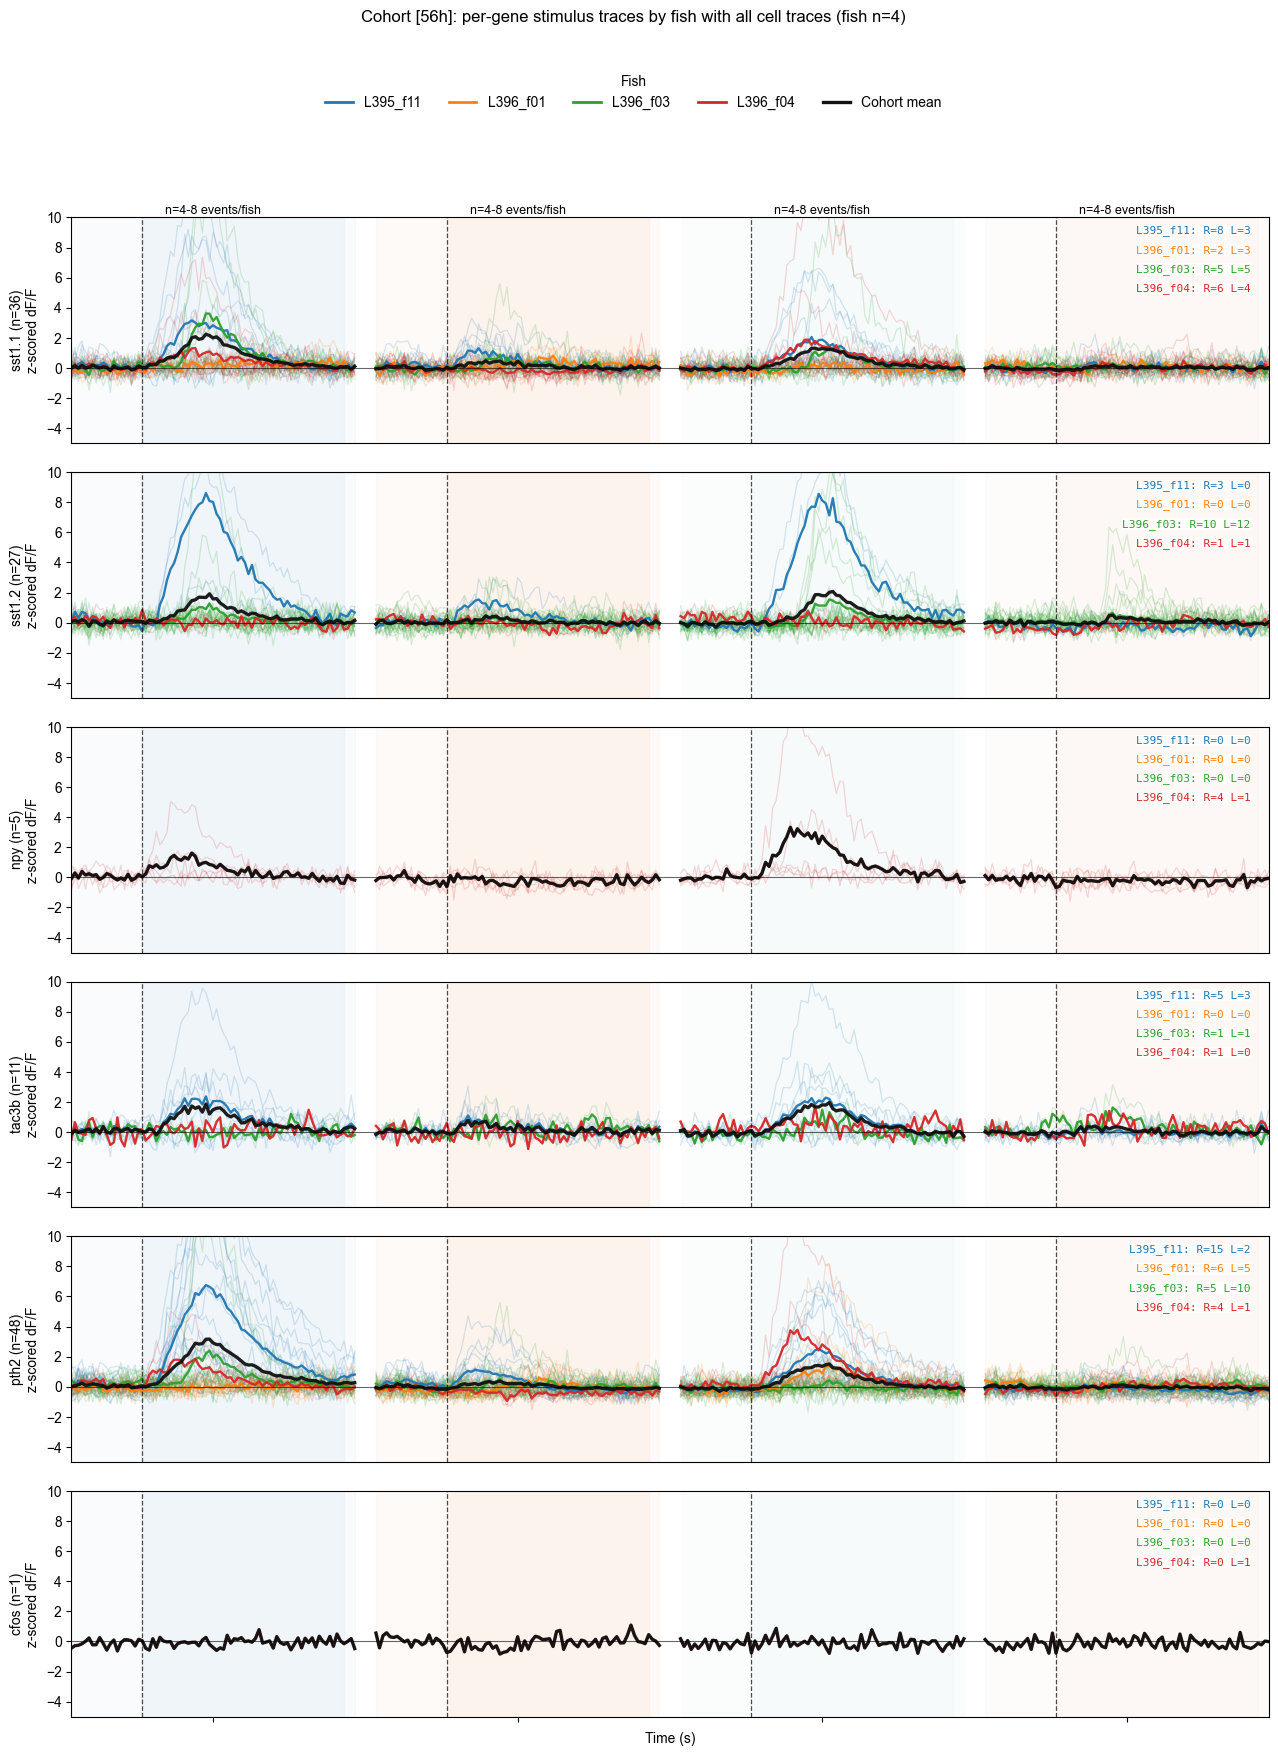

In [53]:
# [56h-cohort] Cohort per-gene traces by fish (from [56h]-style outputs)
try:
    cell_df = cohort_bpi_cells_df.copy()
    results = cohort_results_stim_ipsi_contra
    results_by_fish = cohort_results_stim_ipsi_contra_by_fish
    results_per_cell_by_fish = cohort_results_stim_ipsi_contra_per_cell_by_fish
    tvec = np.asarray(cohort_tvec, dtype=float)
    mode_durations = cohort_mode_durations
    mode_event_counts = cohort_mode_event_counts
    cohort_fish_summary_df = cohort_fish_summary_df.copy()
    cohort_stim_summary_df = cohort_stim_summary_df.copy()
except NameError:
    cached_cohort_state = load_cohort_outputs_from_disk(
        COHORT_OUTDIR,
        load_tables=True,
        load_trace_cache=True,
        verbose=True,
    )
    cell_df = cached_cohort_state.get("cohort_bpi_cells_df", pd.DataFrame()).copy()
    results = cached_cohort_state.get("cohort_results_stim_ipsi_contra", None)
    results_by_fish = cached_cohort_state.get("cohort_results_stim_ipsi_contra_by_fish", None)
    results_per_cell_by_fish = cached_cohort_state.get("cohort_results_stim_ipsi_contra_per_cell_by_fish", None)
    tvec = np.asarray(cached_cohort_state.get("cohort_tvec", []), dtype=float)
    mode_durations = cached_cohort_state.get("cohort_mode_durations", {"LB": [], "LC": []})
    mode_event_counts = cached_cohort_state.get("cohort_mode_event_counts", {"LB": 0, "LC": 0})
    cohort_fish_summary_df = cached_cohort_state.get("cohort_fish_summary_df", pd.DataFrame())
    cohort_stim_summary_df = cached_cohort_state.get("cohort_stim_summary_df", pd.DataFrame())

PLOT_ORDER = ["contra_LB", "contra_LC", "ipsi_LB", "ipsi_LC"]
PANEL_GRID = [["contra_LB", "contra_LC"], ["ipsi_LB", "ipsi_LC"]]
PLOT_TITLES = {
    "contra_LB": "Contra × bout-like",
    "contra_LC": "Contra × continuous",
    "ipsi_LB": "Ipsi × bout-like",
    "ipsi_LC": "Ipsi × continuous",
}

if not isinstance(cell_df, pd.DataFrame) or cell_df.empty:
    raise RuntimeError("cohort_bpi_cells_df missing; run [cohort-build] first.")
if not isinstance(results, dict) or (len(results) == 0):
    raise RuntimeError("cohort_results_stim_ipsi_contra missing; run [cohort-build] first.")
if not isinstance(results_by_fish, dict) or (len(results_by_fish) == 0):
    raise RuntimeError("cohort_results_stim_ipsi_contra_by_fish missing; rerun [cohort-build] to refresh cache.")
if not isinstance(results_per_cell_by_fish, dict) or (count_trace_genes(results_per_cell_by_fish, PLOT_ORDER, nested=True) == 0):
    raise RuntimeError("cohort_results_stim_ipsi_contra_per_cell_by_fish missing or stale; rerun [cohort-build] with FORCE_COHORT_BUILD=True.")
if tvec.size == 0:
    raise RuntimeError("cohort_tvec missing; run [cohort-build] first.")

TRACE_YMIN = -5.0
TRACE_YMAX = 10.0
FIG_WIDTH = 13.0
ROW_HEIGHT = 2.7
HSPACE = 0.40
WSPACE = 0.22

# Backward compatibility: normalize cached panel keys from older casing.
def _normalize_panel_key_map(_panel_map):
    if not isinstance(_panel_map, dict):
        return {}
    out = {}
    for k, v in _panel_map.items():
        key = str(k)
        if key.startswith("Ipsi_"):
            key = "ipsi_" + key[len("Ipsi_"):]
        elif key.startswith("Contra_"):
            key = "contra_" + key[len("Contra_"):]
        out[key] = v
    return out

if isinstance(results_by_fish, dict):
    results_by_fish = {
        str(fid): _normalize_panel_key_map(panel_map)
        for fid, panel_map in results_by_fish.items()
    }

genes_trace = set()
for fish_id, fish_panel_map in results_by_fish.items():
    for panel in PLOT_ORDER:
        genes_trace.update(list(((fish_panel_map or {}).get(panel, {}) or {}).keys()))
genes_present = genes_trace

if not genes_present and isinstance(results, dict) and len(results) > 0:
    for panel in PLOT_ORDER:
        genes_trace.update(list(((results or {}).get(panel, {}) or {}).keys()))
    genes_present = genes_trace
if not genes_present:
    cell_genes = sorted(cell_df.get("gene", pd.Series(dtype=object)).dropna().astype(str).unique().tolist()) if isinstance(cell_df, pd.DataFrame) else []
    summary_has_rows = isinstance(cohort_stim_summary_df, pd.DataFrame) and (not cohort_stim_summary_df.empty)
    if summary_has_rows or cell_genes:
        raise RuntimeError(
            "Cohort [56h] trace cache is stale or incomplete: gene-labelled cohort tables exist but cached per-fish trace summaries are empty. "
            "Rerun [cohort-build] once with FORCE_COHORT_BUILD=True to regenerate the trace cache."
        )
    raise RuntimeError("No genes available for cohort [56h] plot.")

genes = [g for g in GENE_ORDER if g in genes_present] + sorted([g for g in genes_present if g not in GENE_ORDER])
gene_colors = {g: GENE_COLORS.get(g, "#666666") for g in genes}

if "fish_id" in cell_df.columns:
    cell_df["fish_id"] = cell_df["fish_id"].fillna("unknown").astype(str)
if "gene" in cell_df.columns:
    cell_df["gene"] = cell_df["gene"].astype(str)
gene_fish_counts = {str(gene): {} for gene in genes}
gene_sample_sizes = {str(gene): 0 for gene in genes}
fish_order = sorted(set([str(f) for f in results_by_fish.keys()]) | set([str(f) for f in results_per_cell_by_fish.keys()]))
if len(fish_order) == 0:
    raise RuntimeError("No fish-level trace summaries available.")
for gene in genes:
    all_keys = set()
    for fish_id in fish_order:
        responsive_keys = set()
        low_keys = set()
        for panel in PLOT_ORDER:
            roi_map = (((results_per_cell_by_fish.get(fish_id, {}) or {}).get(panel, {}) or {}).get(gene, {}) or {})
            if not isinstance(roi_map, dict):
                continue
            for roi_key, cell_res in roi_map.items():
                key_norm = tuple(roi_key) if isinstance(roi_key, (list, tuple)) else (str(roi_key),)
                all_keys.add((str(fish_id),) + key_norm)
                if bool(cell_res.get("is_low_activity", False)):
                    low_keys.add(key_norm)
                else:
                    responsive_keys.add(key_norm)
        low_only_keys = low_keys - responsive_keys
        gene_fish_counts[str(gene)][str(fish_id)] = {
            "responsive": int(len(responsive_keys)),
            "low": int(len(low_only_keys)),
            "total": int(len(responsive_keys | low_only_keys)),
        }
    gene_sample_sizes[str(gene)] = int(len(all_keys))

panel_event_label_map = {}
for panel in PLOT_ORDER:
    fish_panel_counts = []
    for fish_id in fish_order:
        seg_counts = []
        panel_map = (results_per_cell_by_fish.get(fish_id, {}) or {}).get(panel, {}) or {}
        if not isinstance(panel_map, dict):
            continue
        for roi_map in panel_map.values():
            if not isinstance(roi_map, dict):
                continue
            for cell_res in roi_map.values():
                nseg = pd.to_numeric(pd.Series([cell_res.get('n_segments', np.nan)]), errors='coerce').iloc[0]
                if pd.notna(nseg) and float(nseg) > 0:
                    seg_counts.append(int(round(float(nseg))))
        if seg_counts:
            _vc = pd.Series(seg_counts, dtype='int64').value_counts()
            _top = _vc[_vc == _vc.max()].index.tolist()
            fish_panel_counts.append(int(min(_top)))
    if not fish_panel_counts:
        panel_event_label_map[panel] = 'n=? events/fish'
    else:
        overall_min = min(fish_panel_counts)
        overall_max = max(fish_panel_counts)
        if overall_min == overall_max:
            panel_event_label_map[panel] = f'n={overall_min} events/fish'
        else:
            panel_event_label_map[panel] = f'n={overall_min}-{overall_max} events/fish'

TRACE_BLOCK_GAP_SEC = 3.0
TRACE_X_MIN = -10.0
TRACE_X_MAX = 30.0
TRACE_LINEWIDTH_CELL = 0.9
TRACE_ALPHA_CELL = 0.18
TRACE_LINEWIDTH_FISH_MEAN = 1.7
TRACE_ALPHA_FISH_MEAN = 0.95
TRACE_LINEWIDTH_COHORT_MEAN = 2.4
TRACE_ALPHA_COHORT_MEAN = 0.95
TRACE_BLOCK_BG_ALPHA = 0.12
TRACE_STIM_BG_ALPHA = 0.22
TRACE_MODE_BG_COLORS = {"LB": "#2c7fb8", "LC": "#d95f0e"}
TRACE_SIDE_BG_BLEND = {"contra": 0.78, "ipsi": 0.88}
COUNT_TEXT_SIZE = 8
COUNT_LABEL_X = 0.985
COUNT_LABEL_Y0 = 0.965
COUNT_LABEL_DY = 0.085

def _blend_with_white(color, white_mix):
    rgb = np.asarray(plt.matplotlib.colors.to_rgb(color), dtype=float)
    white_mix = float(np.clip(white_mix, 0.0, 1.0))
    return tuple(((1.0 - white_mix) * rgb) + (white_mix * np.ones(3, dtype=float)))

def _condition_bg_color(panel):
    side = "contra" if str(panel).startswith("contra") else "ipsi"
    mode = "LB" if str(panel).endswith("LB") else "LC"
    base_color = TRACE_MODE_BG_COLORS.get(mode, "#cccccc")
    return _blend_with_white(base_color, TRACE_SIDE_BG_BLEND.get(side, 0.84))

segment_xmin = float(tvec[0]) if TRACE_X_MIN is None else float(TRACE_X_MIN)
segment_xmax = float(tvec[-1]) if TRACE_X_MAX is None else float(TRACE_X_MAX)
plot_mask = (tvec >= segment_xmin) & (tvec <= segment_xmax)
if int(np.count_nonzero(plot_mask)) < 2:
    raise RuntimeError(f"Invalid cohort trace x-range [{segment_xmin}, {segment_xmax}] leaves fewer than 2 timepoints.")
plot_tvec = tvec[plot_mask]
block_span = float(plot_tvec[-1] - plot_tvec[0])
block_offsets = {
    panel: (idx * (block_span + float(TRACE_BLOCK_GAP_SEC))) - float(plot_tvec[0])
    for idx, panel in enumerate(PLOT_ORDER)
}
block_starts = {panel: float(plot_tvec[0] + shift) for panel, shift in block_offsets.items()}
block_ends = {panel: float(plot_tvec[-1] + shift) for panel, shift in block_offsets.items()}
block_centers = {panel: 0.5 * (block_starts[panel] + block_ends[panel]) for panel in PLOT_ORDER}
onset_positions = {panel: float(0.0 + shift) for panel, shift in block_offsets.items()}
merged_xlim = (min(block_starts.values()), max(block_ends.values()))
merged_xticks = [block_centers[panel] for panel in PLOT_ORDER]
merged_xticklabels = [PLOT_TITLES.get(panel, panel).replace(" × ", "\n") for panel in PLOT_ORDER]

n_rows = max(1, len(genes))
fig, axes = plt.subplots(
    n_rows,
    1,
    figsize=(FIG_WIDTH, ROW_HEIGHT * n_rows + 1.4),
    sharex=True,
    sharey=True,
)
axes = np.atleast_1d(axes)

fish_cmap = plt.get_cmap("tab10") if len(fish_order) <= 10 else plt.get_cmap("tab20")
fish_colors = {fid: fish_cmap(i % fish_cmap.N) for i, fid in enumerate(fish_order)}
cohort_mean_color = "#111111"

for r_idx, gene in enumerate(genes):
    ax = axes[r_idx]
    n_lines = 0
    for panel in PLOT_ORDER:
        x_block = plot_tvec + block_offsets[panel]
        bg_color = _condition_bg_color(panel)
        ax.axvspan(block_starts[panel], block_ends[panel], color=bg_color, alpha=TRACE_BLOCK_BG_ALPHA, zorder=0)

        mode = "LB" if panel.endswith("LB") else "LC"
        dur_vals = mode_durations.get(mode, [])
        if isinstance(dur_vals, (list, tuple, np.ndarray)) and len(dur_vals) > 0:
            stim_dur = float(np.median(np.asarray(dur_vals, dtype=float)))
            if np.isfinite(stim_dur) and stim_dur > 0:
                stim_start_local = max(0.0, segment_xmin)
                stim_end_local = min(float(stim_dur), segment_xmax)
                if stim_end_local > stim_start_local:
                    ax.axvspan(
                        block_offsets[panel] + stim_start_local,
                        block_offsets[panel] + stim_end_local,
                        color=bg_color,
                        alpha=TRACE_STIM_BG_ALPHA,
                        zorder=0,
                    )

        for fish_id in fish_order:
            roi_map = (((results_per_cell_by_fish.get(fish_id, {}) or {}).get(panel, {}) or {}).get(gene, {}) or {})
            if not isinstance(roi_map, dict) or not roi_map:
                continue
            for roi_key, cell_res in sorted(roi_map.items(), key=lambda kv: str(kv[0])):
                mean = np.asarray(cell_res.get("mean", []), dtype=float)
                if mean.size != tvec.size:
                    continue
                ax.plot(
                    x_block,
                    mean[plot_mask],
                    color=fish_colors[fish_id],
                    linewidth=TRACE_LINEWIDTH_CELL,
                    alpha=TRACE_ALPHA_CELL,
                )
                n_lines += 1

        for fish_id in fish_order:
            fish_panel_map = results_by_fish.get(fish_id, {}) or {}
            res = (fish_panel_map.get(panel, {}) or {}).get(gene, None)
            if res is None:
                continue
            n_segments = int(res.get("n_segments", 0))
            n_cells = int(res.get("n_cells", 0))
            if n_segments < MIN_SEGMENTS or n_cells < MIN_CELLS:
                continue
            mean = np.asarray(res.get("mean", []), dtype=float)
            if mean.size != tvec.size:
                continue
            ax.plot(
                x_block,
                mean[plot_mask],
                color=fish_colors[fish_id],
                linewidth=TRACE_LINEWIDTH_FISH_MEAN,
                alpha=TRACE_ALPHA_FISH_MEAN,
            )

        cohort_res = (results.get(panel, {}) or {}).get(gene, None)
        if cohort_res is not None:
            cohort_mean = np.asarray(cohort_res.get("mean", []), dtype=float)
            if cohort_mean.size == tvec.size:
                ax.plot(
                    x_block,
                    cohort_mean[plot_mask],
                    color=cohort_mean_color,
                    linewidth=TRACE_LINEWIDTH_COHORT_MEAN,
                    alpha=TRACE_ALPHA_COHORT_MEAN,
                )

        if segment_xmin <= 0.0 <= segment_xmax:
            ax.axvline(onset_positions[panel], color="k", linestyle="--", linewidth=0.9, alpha=0.7)

    ax.axhline(0, color="k", linewidth=0.8, alpha=0.6)
    ax.set_xlim(*merged_xlim)
    ax.set_ylim(TRACE_YMIN, TRACE_YMAX)
    ax.set_ylabel(f"{gene} (n={gene_sample_sizes.get(str(gene), 0)})\nz-scored dF/F")

    if r_idx == 0:
        for panel in PLOT_ORDER:
            ax.text(
                block_centers[panel],
                1.005,
                panel_event_label_map.get(panel, 'n=? events/fish'),
                transform=ax.get_xaxis_transform(),
                ha="center",
                va="bottom",
                fontsize=9,
            )

    if n_lines == 0:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", fontsize=8, alpha=0.8)

    for idx, fid in enumerate(fish_order):
        fish_counts = gene_fish_counts.get(str(gene), {}).get(fid, {"responsive": 0, "low": 0})
        resp_n = int(fish_counts.get("responsive", 0))
        low_n = int(fish_counts.get("low", 0))
        ax.text(
            COUNT_LABEL_X,
            COUNT_LABEL_Y0 - (idx * COUNT_LABEL_DY),
            f"{fid}: R={resp_n} L={low_n}",
            transform=ax.transAxes,
            ha='right',
            va='top',
            fontsize=COUNT_TEXT_SIZE,
            fontfamily='monospace',
            color=fish_colors[fid],
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.72, pad=0.18),
            clip_on=True,
        )

if len(axes) > 0:
    axes[-1].set_xticks(merged_xticks)
    axes[-1].set_xticklabels(merged_xticklabels)
    axes[-1].set_xlabel("Time (s)")
for ax in axes[:-1]:
    ax.set_xticks(merged_xticks)
    ax.set_xticklabels([])
    ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

handles = [
    plt.Line2D([0], [0], color=fish_colors[fid], lw=2, label=str(fid))
    for fid in fish_order
]
handles.append(plt.Line2D([0], [0], color=cohort_mean_color, lw=2.4, label="Cohort mean"))
fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 0.965), ncol=min(6, len(handles)), frameon=False, title="Fish")

n_fish_ok = int(cohort_fish_summary_df.get("ok", pd.Series(dtype=bool)).sum()) if isinstance(cohort_fish_summary_df, pd.DataFrame) else 0
fig.suptitle(f"Cohort [56h]: per-gene stimulus traces by fish with all cell traces (fish n={n_fish_ok})", y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.91])

out_path = COHORT_OUTDIR / "cohort_56h_per_gene_by_fish.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight")
print(f"[56h-cohort] saved: {out_path}")

FIG_56H_COHORT_LAST = fig
try:
    fig.canvas.draw()
    FIG_56H_COHORT_RGBA = np.asarray(fig.canvas.buffer_rgba()).copy()
except Exception:
    FIG_56H_COHORT_RGBA = None

plt.show()



[56g-cohort] cells=76; BPI col=bpi; activity cols=(mean_bout_zdff, mean_cont_zdff); |BPI|<=0.100: 13; near-zero+low=6; near-zero+high=7; activity-threshold=0.2771 (q20)
[56g-cohort] saved: /Users/ddharmap/dataProcessing/2p_HCR/analysis/midThesis/cohort_outputs/multi_fish_56h_56g/cohort_56g.png


interpretation,gene,near-zero BPI + high activity,near-zero BPI + low activity,non-zero BPI
0,npy,1,1,2
1,pth2,1,1,28
2,sst1.1,3,3,15
3,sst1.2,1,0,13
4,tac3b,1,1,5


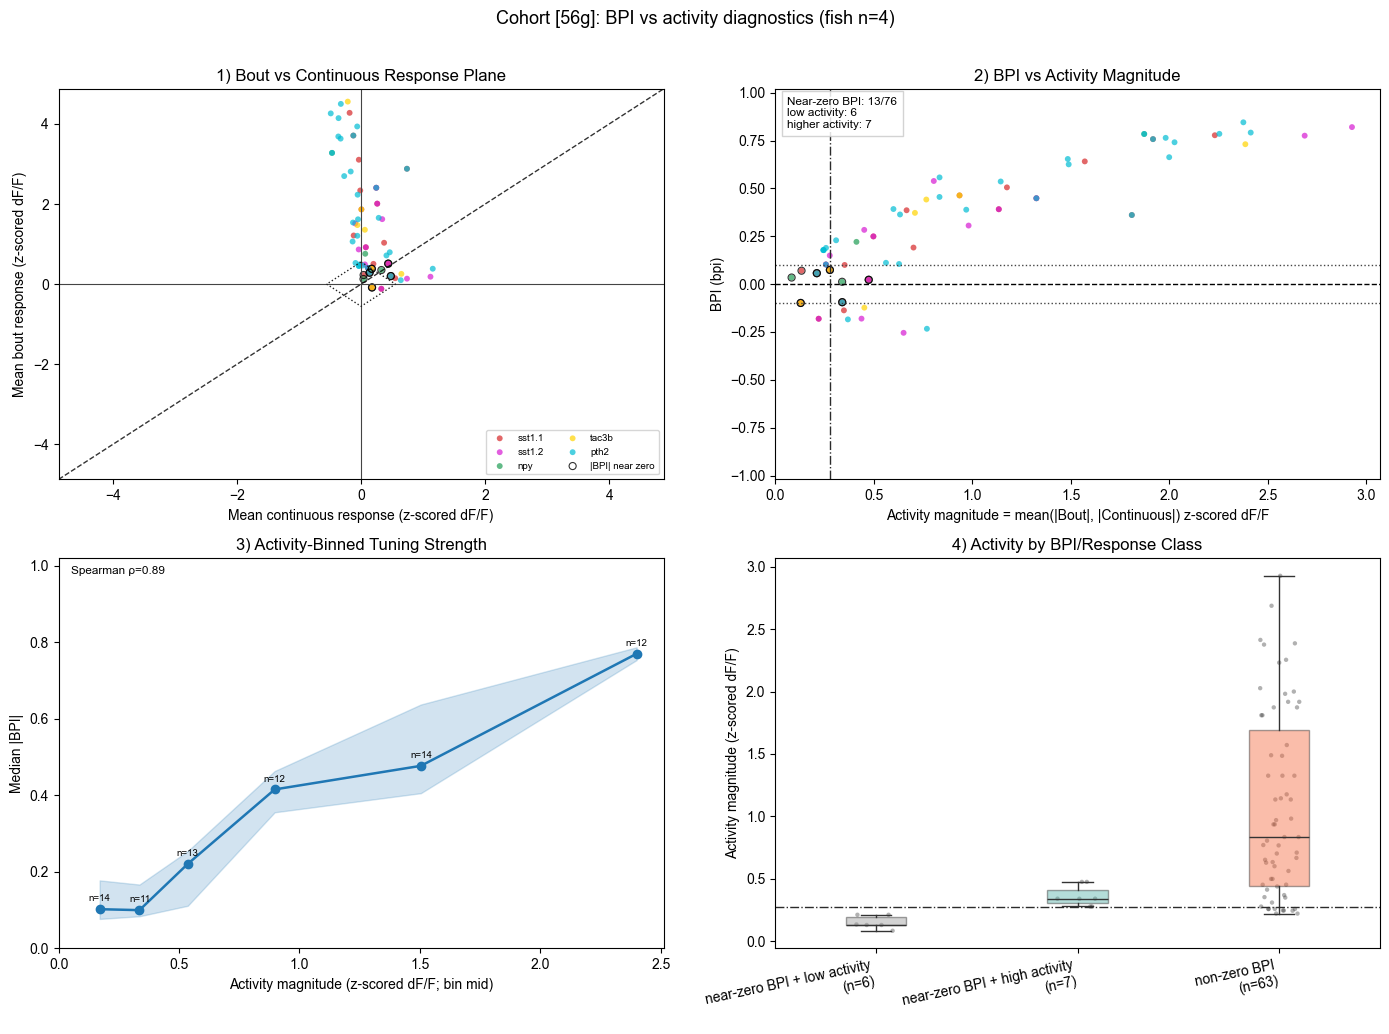

In [50]:
# [56g-cohort] Cohort BPI/activity diagnostics (2x2)
try:
    df = cohort_bpi_cells_df.copy()
except NameError:
    cached_cohort_state = load_cohort_outputs_from_disk(
        COHORT_OUTDIR,
        load_tables=True,
        load_trace_cache=False,
        verbose=True,
    )
    df = cached_cohort_state.get("cohort_bpi_cells_df", pd.DataFrame()).copy()
    cohort_fish_summary_df = cached_cohort_state.get("cohort_fish_summary_df", pd.DataFrame())

if not isinstance(df, pd.DataFrame) or df.empty:
    raise RuntimeError("cohort_bpi_cells_df missing; run [cohort-build] first.")

BPI_ZERO_BAND = 0.10
BPI_NONRESP_Q = 0.20
BPI_NONRESP_ACTIVITY_THRESHOLD = None
BPI_POINT_ALPHA = 0.7
BPI_POINT_SIZE = 18.0
BPI_N_ACTIVITY_BINS = 6
BPI_INDEX_COL = 'bpi'

if not (0.0 <= BPI_NONRESP_Q <= 1.0):
    print(f"[56g-cohort] invalid BPI_NONRESP_Q={BPI_NONRESP_Q}; using 0.20")
    BPI_NONRESP_Q = 0.20
if BPI_N_ACTIVITY_BINS < 2:
    BPI_N_ACTIVITY_BINS = 2

if {'mean_bout_zdff', 'mean_cont_zdff'}.issubset(df.columns):
    bout_col = 'mean_bout_zdff'
    cont_col = 'mean_cont_zdff'
    activity_label = 'z-scored dF/F'
elif {'mean_bout_dff', 'mean_cont_dff'}.issubset(df.columns):
    bout_col = 'mean_bout_dff'
    cont_col = 'mean_cont_dff'
    activity_label = 'dF/F'
    print('[56g-cohort] WARNING: z-scored columns missing; falling back to raw dF/F.')
else:
    raise RuntimeError('cohort_bpi_cells_df missing response columns needed for [56g].')

if BPI_INDEX_COL not in df.columns:
    fallback_bpi = 'bpi_z' if 'bpi_z' in df.columns else 'bpi'
    print(f"[56g-cohort] BPI_INDEX_COL={BPI_INDEX_COL} missing; using {fallback_bpi}")
    BPI_INDEX_COL = fallback_bpi

for col in [BPI_INDEX_COL, bout_col, cont_col]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['activity_mag'] = (df[bout_col].abs() + df[cont_col].abs()) / 2.0
df['bpi_metric'] = df[BPI_INDEX_COL]
df['abs_bpi'] = df['bpi_metric'].abs()
df = df[
    np.isfinite(df['activity_mag'])
    & np.isfinite(df['bpi_metric'])
    & np.isfinite(df[bout_col])
    & np.isfinite(df[cont_col])
].copy()

if df.empty:
    raise RuntimeError('No finite rows left for [56g-cohort].')

if BPI_NONRESP_ACTIVITY_THRESHOLD is None:
    thr = float(np.nanquantile(df['activity_mag'].to_numpy(dtype=float), BPI_NONRESP_Q))
    thr_label = f"q{int(round(BPI_NONRESP_Q * 100.0))}"
else:
    thr = float(BPI_NONRESP_ACTIVITY_THRESHOLD)
    thr_label = 'manual'

df['is_bpi_near_zero'] = df['bpi_metric'].abs() <= float(BPI_ZERO_BAND)
df['is_nonresponsive'] = df['activity_mag'] <= float(thr) if np.isfinite(thr) else False
df['interpretation'] = np.where(
    df['is_bpi_near_zero'] & df['is_nonresponsive'],
    'near-zero BPI + low activity',
    np.where(
        df['is_bpi_near_zero'] & (~df['is_nonresponsive']),
        'near-zero BPI + high activity',
        'non-zero BPI',
    ),
)

n_total = int(len(df))
n_nz = int(df['is_bpi_near_zero'].sum())
n_nz_low = int((df['is_bpi_near_zero'] & df['is_nonresponsive']).sum())
n_nz_high = int((df['is_bpi_near_zero'] & (~df['is_nonresponsive'])).sum())

print(
    f"[56g-cohort] cells={n_total}; BPI col={BPI_INDEX_COL}; activity cols=({bout_col}, {cont_col}); "
    f"|BPI|<={BPI_ZERO_BAND:.3f}: {n_nz}; near-zero+low={n_nz_low}; near-zero+high={n_nz_high}; "
    f"activity-threshold={thr:.4f} ({thr_label})"
)

genes_present = sorted(df['gene'].dropna().astype(str).unique().tolist())
gene_order = [g for g in GENE_ORDER if g in genes_present] + [g for g in genes_present if g not in GENE_ORDER]

fig, axes = plt.subplots(2, 2, figsize=(14, 10.5))
ax_plane = axes[0, 0]
ax_quad = axes[0, 1]
ax_bins = axes[1, 0]
ax_group = axes[1, 1]

# 1) Bout vs Continuous response plane
for gene in gene_order:
    sub = df[df['gene'].astype(str) == str(gene)]
    if sub.empty:
        continue
    ax_plane.scatter(
        sub[cont_col].to_numpy(dtype=float),
        sub[bout_col].to_numpy(dtype=float),
        s=BPI_POINT_SIZE,
        alpha=BPI_POINT_ALPHA,
        color=GENE_COLORS.get(gene, '#777777'),
        edgecolors='none',
        label=str(gene),
    )

sub_nz = df[df['is_bpi_near_zero']]
if not sub_nz.empty:
    ax_plane.scatter(
        sub_nz[cont_col].to_numpy(dtype=float),
        sub_nz[bout_col].to_numpy(dtype=float),
        s=max(14.0, BPI_POINT_SIZE + 8.0),
        facecolors='none',
        edgecolors='black',
        linewidths=0.8,
        alpha=0.8,
        label='|BPI| near zero',
    )

combo = np.concatenate([
    np.abs(df[cont_col].to_numpy(dtype=float)),
    np.abs(df[bout_col].to_numpy(dtype=float)),
])
vmax = float(np.nanpercentile(combo, 99)) if combo.size else 1.0
if not np.isfinite(vmax) or vmax <= 0:
    vmax = 1.0

ax_plane.plot([-vmax, vmax], [-vmax, vmax], linestyle='--', color='black', linewidth=1.0, alpha=0.8)
ax_plane.axhline(0.0, color='#444444', linewidth=0.8)
ax_plane.axvline(0.0, color='#444444', linewidth=0.8)
if np.isfinite(thr):
    diamond = np.array([
        [0.0, 2.0 * thr],
        [2.0 * thr, 0.0],
        [0.0, -2.0 * thr],
        [-2.0 * thr, 0.0],
        [0.0, 2.0 * thr],
    ])
    ax_plane.plot(diamond[:, 0], diamond[:, 1], linestyle=':', color='#222222', linewidth=1.0)
ax_plane.set_xlim(-vmax, vmax)
ax_plane.set_ylim(-vmax, vmax)
ax_plane.set_xlabel(f'Mean continuous response ({activity_label})')
ax_plane.set_ylabel(f'Mean bout response ({activity_label})')
ax_plane.set_title('1) Bout vs Continuous Response Plane')

handles, labels = ax_plane.get_legend_handles_labels()
if handles:
    ax_plane.legend(handles, labels, fontsize=7, ncol=2, loc='lower right')

# 2) BPI vs activity magnitude
for gene in gene_order:
    sub = df[df['gene'].astype(str) == str(gene)]
    if sub.empty:
        continue
    ax_quad.scatter(
        sub['activity_mag'].to_numpy(dtype=float),
        sub['bpi_metric'].to_numpy(dtype=float),
        s=BPI_POINT_SIZE,
        alpha=BPI_POINT_ALPHA,
        color=GENE_COLORS.get(gene, '#777777'),
        edgecolors='none',
    )
if not sub_nz.empty:
    ax_quad.scatter(
        sub_nz['activity_mag'].to_numpy(dtype=float),
        sub_nz['bpi_metric'].to_numpy(dtype=float),
        s=max(14.0, BPI_POINT_SIZE + 8.0),
        facecolors='none',
        edgecolors='black',
        linewidths=0.8,
        alpha=0.8,
    )

ax_quad.axhline(0.0, color='black', linestyle='--', linewidth=1.0)
ax_quad.axhline(float(BPI_ZERO_BAND), color='#444444', linestyle=':', linewidth=1.0)
ax_quad.axhline(-float(BPI_ZERO_BAND), color='#444444', linestyle=':', linewidth=1.0)
if np.isfinite(thr):
    ax_quad.axvline(float(thr), color='#2b2b2b', linestyle='-.', linewidth=1.0)

ax_quad.set_xlabel(f'Activity magnitude = mean(|Bout|, |Continuous|) {activity_label}')
ax_quad.set_ylabel(f'BPI ({BPI_INDEX_COL})')
ax_quad.set_ylim(-1.02, 1.02)
ax_quad.set_xlim(left=0)
ax_quad.set_title('2) BPI vs Activity Magnitude')

txt = (
    f"Near-zero BPI: {n_nz}/{n_total}\n"
    f"low activity: {n_nz_low}\n"
    f"higher activity: {n_nz_high}"
)
ax_quad.text(
    0.02,
    0.98,
    txt,
    transform=ax_quad.transAxes,
    ha='left',
    va='top',
    fontsize=8.5,
    bbox=dict(facecolor='white', edgecolor='#cccccc', alpha=0.85),
)

# 3) Activity-binned tuning strength
binned_df = pd.DataFrame()
n_bins = min(BPI_N_ACTIVITY_BINS, int(df['activity_mag'].nunique()))
if n_bins >= 2:
    try:
        bin_cat = pd.qcut(df['activity_mag'], q=n_bins, duplicates='drop')
        tmp = df.copy()
        tmp['_activity_bin'] = bin_cat
        rows = []
        for b, sub in tmp.groupby('_activity_bin', observed=False):
            vals = sub['abs_bpi'].to_numpy(dtype=float)
            if vals.size == 0:
                continue
            rows.append({
                'bin': str(b),
                'bin_lo': float(b.left),
                'bin_hi': float(b.right),
                'bin_mid': float((b.left + b.right) / 2.0),
                'n_cells': int(vals.size),
                'median_abs_bpi': float(np.nanmedian(vals)),
                'q25_abs_bpi': float(np.nanquantile(vals, 0.25)),
                'q75_abs_bpi': float(np.nanquantile(vals, 0.75)),
            })
        binned_df = pd.DataFrame(rows).sort_values('bin_mid').reset_index(drop=True)
    except Exception:
        binned_df = pd.DataFrame()

if binned_df.empty:
    ax_bins.text(0.5, 0.5, 'Insufficient data for binning', transform=ax_bins.transAxes, ha='center', va='center')
    ax_bins.set_title('3) Activity-Binned |BPI|')
    ax_bins.set_xlabel(f'Activity magnitude ({activity_label})')
    ax_bins.set_ylabel('Median |BPI|')
else:
    x = binned_df['bin_mid'].to_numpy(dtype=float)
    y = binned_df['median_abs_bpi'].to_numpy(dtype=float)
    y25 = binned_df['q25_abs_bpi'].to_numpy(dtype=float)
    y75 = binned_df['q75_abs_bpi'].to_numpy(dtype=float)
    ax_bins.plot(x, y, marker='o', color='#1f77b4', linewidth=1.8)
    ax_bins.fill_between(x, y25, y75, alpha=0.2, color='#1f77b4')
    for _, r in binned_df.iterrows():
        ax_bins.text(float(r['bin_mid']), float(r['median_abs_bpi']) + 0.015, f"n={int(r['n_cells'])}", ha='center', va='bottom', fontsize=7)
    rho = pd.Series(df['activity_mag']).corr(pd.Series(df['abs_bpi']), method='spearman')
    if np.isfinite(rho):
        ax_bins.text(0.02, 0.98, f"Spearman ρ={rho:.2f}", transform=ax_bins.transAxes, ha='left', va='top', fontsize=8.5)
    ax_bins.set_title('3) Activity-Binned Tuning Strength')
    ax_bins.set_xlabel(f'Activity magnitude ({activity_label}; bin mid)')
    ax_bins.set_ylabel('Median |BPI|')
    ax_bins.set_ylim(0, 1.02)
    ax_bins.set_xlim(left=0)

# 4) Activity by BPI/response class
group_order = [
    'near-zero BPI + low activity',
    'near-zero BPI + high activity',
    'non-zero BPI',
]
group_colors = {
    'near-zero BPI + low activity': '#9e9e9e',
    'near-zero BPI + high activity': '#5ab4ac',
    'non-zero BPI': '#f46d43',
}

group_data = []
group_labels = []
for g in group_order:
    vals = df.loc[df['interpretation'] == g, 'activity_mag'].to_numpy(dtype=float)
    if vals.size == 0:
        continue
    group_data.append(vals)
    group_labels.append(f"{g}\n(n={vals.size})")

if not group_data:
    ax_group.text(0.5, 0.5, 'No group data', transform=ax_group.transAxes, ha='center', va='center')
    ax_group.set_title('4) Activity by BPI/Response Class')
    ax_group.set_ylabel(f'Activity magnitude ({activity_label})')
else:
    bp = ax_group.boxplot(group_data, patch_artist=True, showfliers=False)
    for i, patch in enumerate(bp['boxes']):
        base = group_labels[i].split('\n')[0]
        patch.set_facecolor(group_colors.get(base, '#bbbbbb'))
        patch.set_alpha(0.45)
        patch.set_edgecolor('#333333')
    for key in ('whiskers', 'caps', 'medians'):
        for artist in bp[key]:
            artist.set_color('#333333')
            artist.set_linewidth(1.0)

    rng = np.random.default_rng(0)
    for i, vals in enumerate(group_data, start=1):
        jitter = rng.uniform(-0.10, 0.10, size=vals.size)
        ax_group.scatter(
            np.full(vals.size, i) + jitter,
            vals,
            s=10,
            alpha=0.35,
            color='#222222',
            edgecolors='none',
        )

    ax_group.set_xticks(np.arange(1, len(group_labels) + 1))
    ax_group.set_xticklabels(group_labels, rotation=12, ha='right')
    ax_group.set_ylabel(f'Activity magnitude ({activity_label})')
    ax_group.set_title('4) Activity by BPI/Response Class')
    if np.isfinite(thr):
        ax_group.axhline(float(thr), color='#2b2b2b', linestyle='-.', linewidth=1.0)

n_fish_ok = int(cohort_fish_summary_df.get('ok', pd.Series(dtype=bool)).sum()) if isinstance(cohort_fish_summary_df, pd.DataFrame) else 0
fig.suptitle(f'Cohort [56g]: BPI vs activity diagnostics (fish n={n_fish_ok})', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.97])

out_path = COHORT_OUTDIR / 'cohort_56g.png'
fig.savefig(out_path, dpi=200, bbox_inches='tight')
print(f"[56g-cohort] saved: {out_path}")

cohort_bpi_activity_df = df.copy()
cohort_bpi_activity_bins_df = binned_df.copy()
FIG_56G_COHORT_LAST = fig
try:
    fig.canvas.draw()
    FIG_56G_COHORT_RGBA = np.asarray(fig.canvas.buffer_rgba()).copy()
except Exception:
    FIG_56G_COHORT_RGBA = None

try:
    breakdown = (
        df.groupby(['gene', 'interpretation'])
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )
    cohort_bpi_activity_breakdown_df = breakdown.copy()
    display(breakdown)
except Exception:
    pass

plt.show()



/var/folders/qg/mcw76_dj3gq7p4vz0sd2w_hh0000gn/T/ipykernel_7750/1599849433.py:503: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.06, 0, 1, 0.97])


[cohort-auc] Saved: /Users/ddharmap/dataProcessing/2p_HCR/analysis/midThesis/cohort_outputs/multi_fish_56h_56g/cohort_50l_auc_ipsi_contra.png


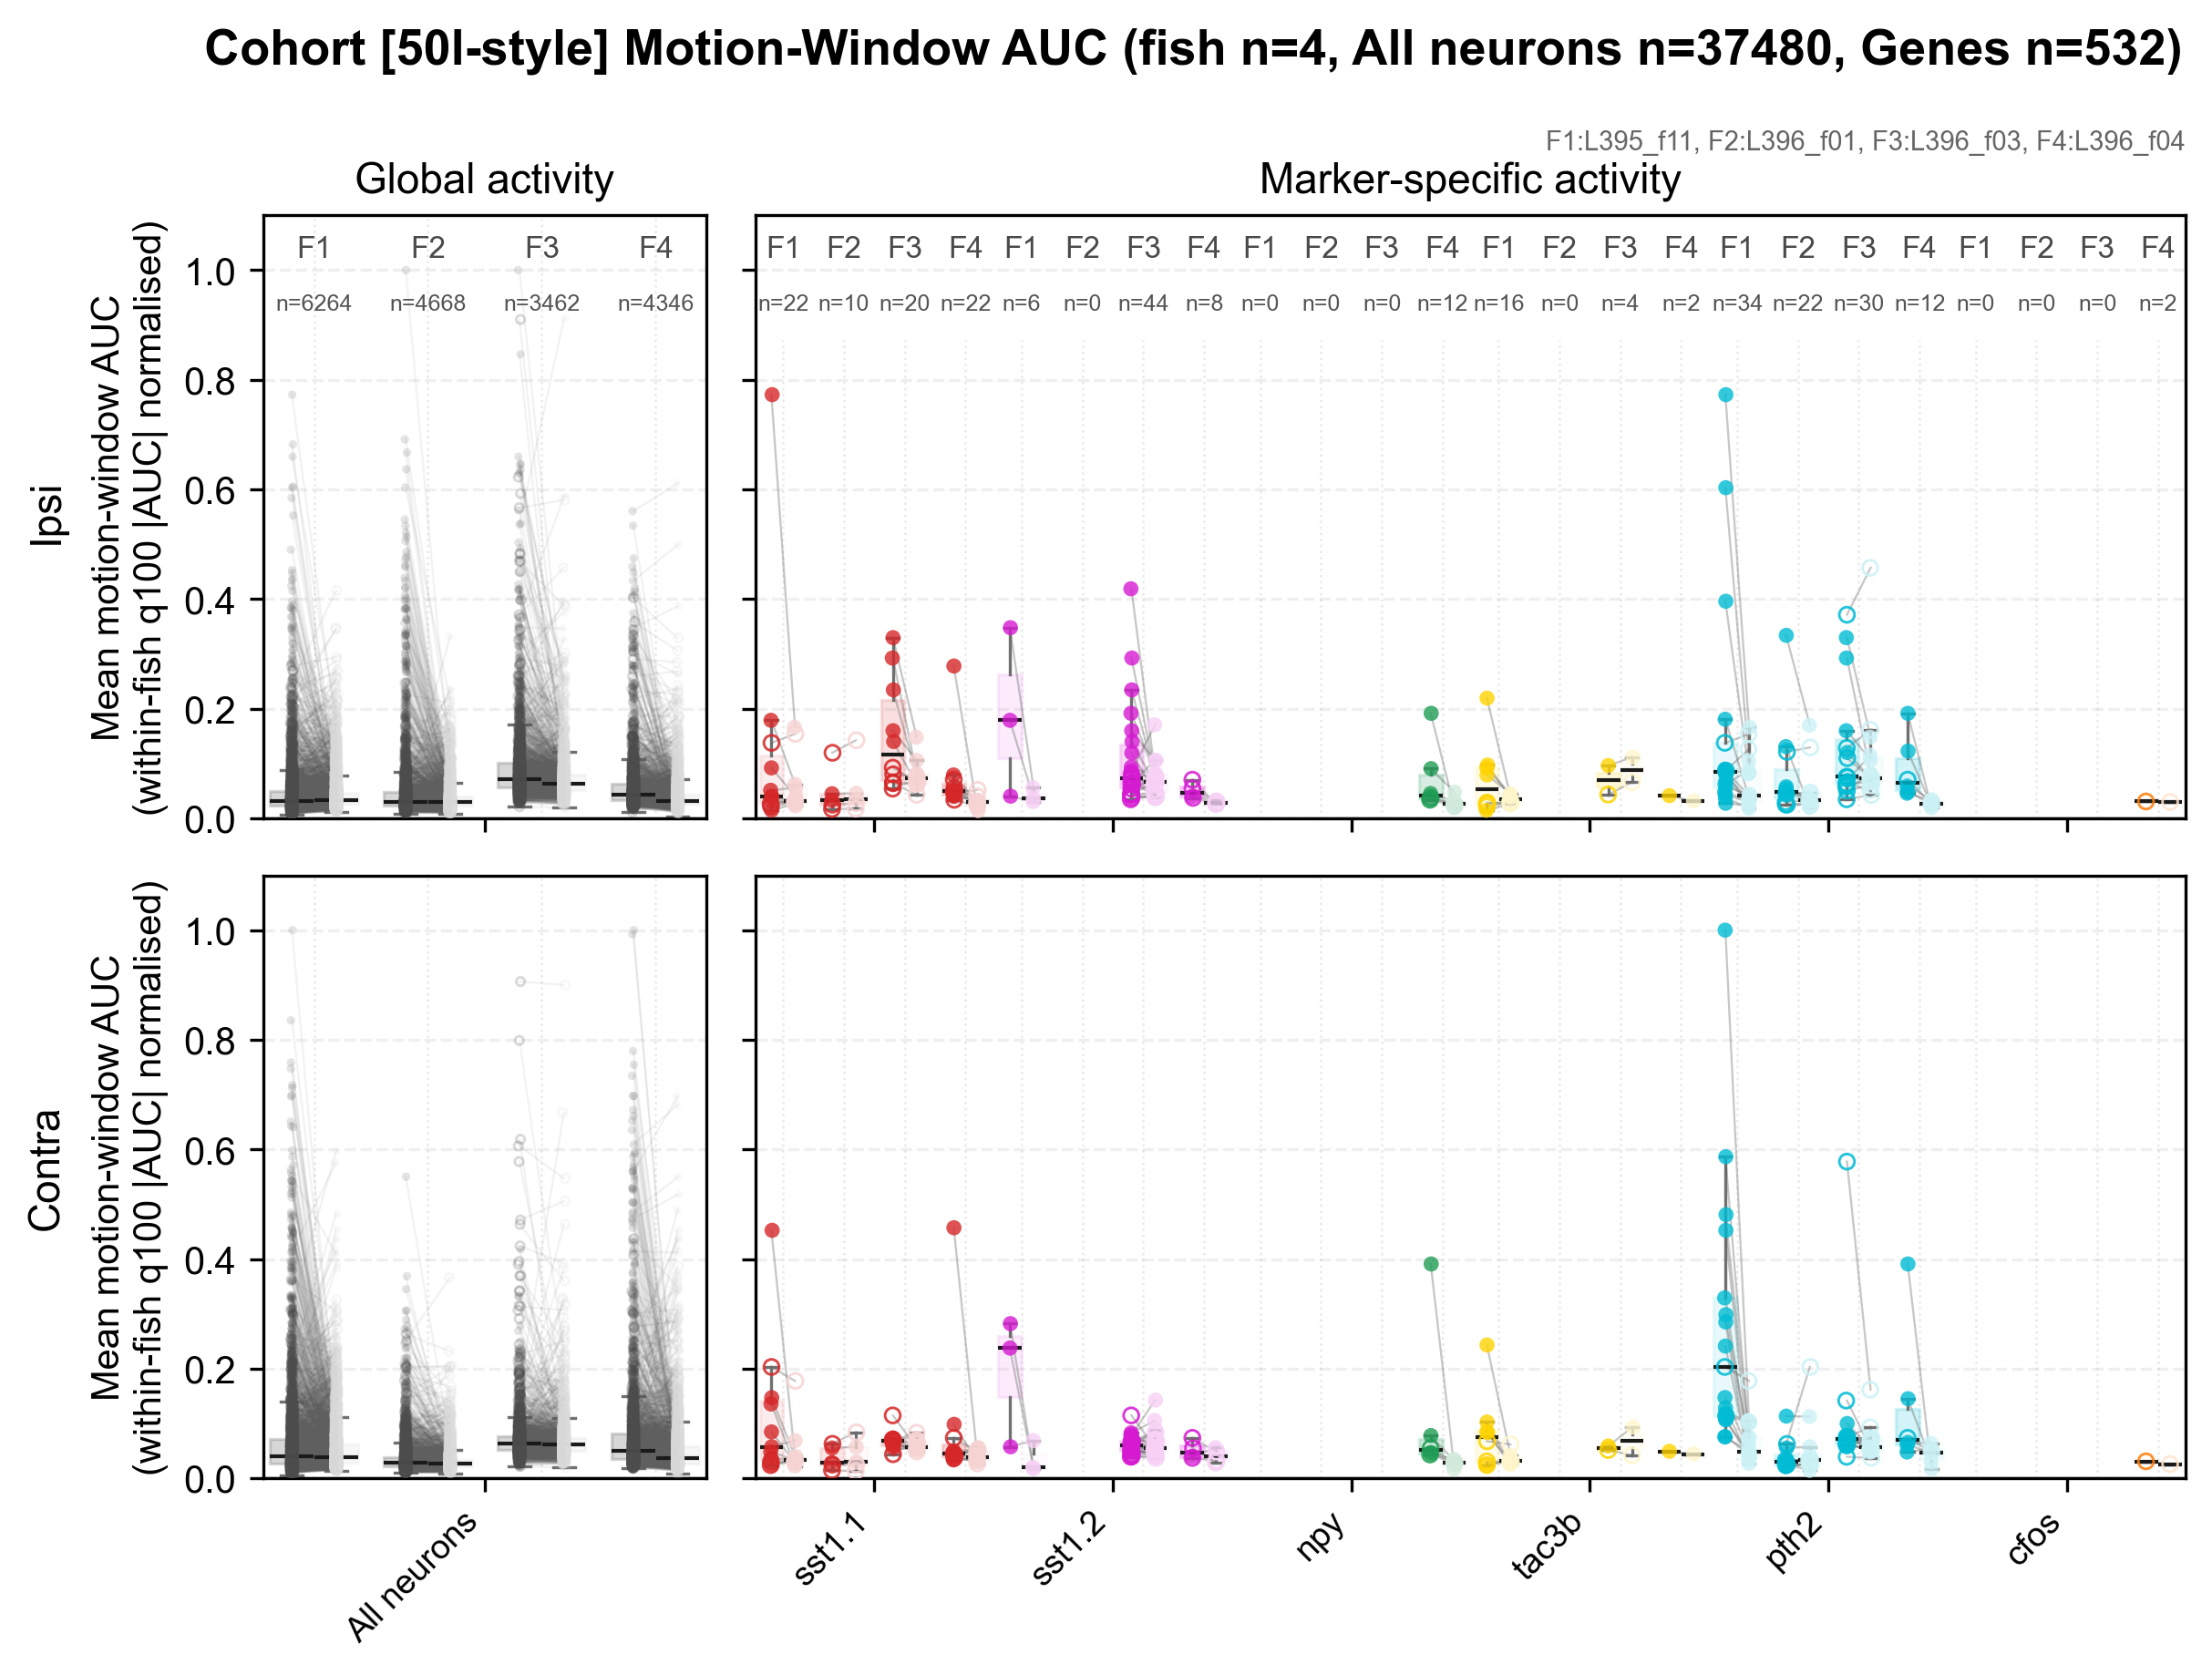

[cohort-auc] Complete: Cohort AUC visualization generated
  - All neurons total: 37480
  - Genes total: 532
  - Genes present: sst1.1, sst1.2, npy, tac3b, pth2, cfos
  - Fish: L395_f11, L396_f01, L396_f03, L396_f04


In [51]:
# [cohort-auc] Cohort motion-window AUC pair plots (ipsi/contra × bout/continuous)
import matplotlib.colors as mcolors
import matplotlib as mpl
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Typography: prefer Aptos (Body), with sensible fallbacks
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Aptos', 'Aptos (Body)', 'Calibri', 'Arial', 'DejaVu Sans']

# AUC figure parameters
AUC_FIGURE_WIDTH = 11.34 * 0.80  # A4 landscape width with ~20% side clearance
AUC_FIGURE_HEIGHT = 6
AUC_FIGURE_DPI = 300
AUC_BOX_WIDTH = 0.30  # requested minimum visual width
AUC_POINT_SIZE_ALL = 5.0
AUC_POINT_SIZE_GENE = 16.0
AUC_FISH_CLUSTER_SPAN = 0.56 
AUC_WITHIN_FISH_JITTER = 0.010
AUC_PAIR_MODE_OFFSET = 0.01
AUC_PAIR_MODE_OFFSET_FISH = 0.08  # target half-offset for bout/continuous within each fish
AUC_POINT_ALPHA_ALL = 0.15
AUC_POINT_ALPHA_GENE = 0.80
AUC_PAIR_LINE_ALPHA_ALL = 0.08
AUC_CONT_LIGHTEN = 0.80  # stronger contrast: continuous appears much lighter than bout
AUC_ROW_LABEL_FONT_SIZE = 11
AUC_LANE_LABEL_FONT_SIZE = 8
AUC_LANE_GUIDE_ALPHA = 0.18

AUC_LANE_LABEL_Y_OFFSET_FRAC = -0.08  # negative values move lane labels downward
AUC_LANE_COUNT_FONT_SIZE = 6
AUC_LANE_COUNT_Y_OFFSET_FRAC = -0.13  # place n-labels below lane labels

AUC_NORM_ABS_QUANTILE = 1.0  # within-fish scale uses q of |AUC|; set e.g. 0.90, 0.95, 0.99, 1.00 (=max)
AUC_Y_PAD = 0.10

# Response/BPI color settings from [50l-style]
RESPONSE_ACTIVE = 'Responsive neurons'
RESPONSE_LOW = 'Low activity'
RESPONSE_LOW_NORM = 'low activity'
RESPONSE_UNAVAILABLE = 'Response unavailable'
BPI_WEAK = 'weak-response'
BPI_BOUT = 'bout-responsive'
BPI_CONT = 'continuous-responsive'
BPI_BOTH = 'both-responsive'
BPI_LOW = 'low activity'
BPI_UNAVAILABLE = 'response unavailable'

response_colors_auc = {
    RESPONSE_ACTIVE: '#1b9e77',
    RESPONSE_LOW: '#8d8d8d',
    RESPONSE_UNAVAILABLE: '#d9d9d9',
}
bpi_colors_auc = {
    BPI_BOUT: '#2c7fb8',
    BPI_CONT: '#d95f0e',
    BPI_BOTH: '#c7b37a',
    BPI_LOW: '#9e9e9e',
    BPI_UNAVAILABLE: '#ececec',
}

# Try to load from memory or disk
try:
    points_df_cohort = cohort_motion_auc_plot_points.copy()
    counts_df_cohort = cohort_motion_auc_plot_counts.copy()
    cached_auc = True
except NameError:
    cached_auc = False
    points_csv = COHORT_OUTDIR / 'cohort_motion_auc_plot_points.csv'
    counts_csv = COHORT_OUTDIR / 'cohort_motion_auc_plot_counts.csv'
    
    if points_csv.exists() and counts_csv.exists():
        points_df_cohort = pd.read_csv(points_csv)
        counts_df_cohort = pd.read_csv(counts_csv)
        cached_auc = True
        print('[cohort-auc] Loaded cached AUC CSVs from disk')
    else:
        # Load single-fish AUC data and aggregate
        all_points = []
        all_counts = []
        
        for spec in FISH_SPECS:
            owner = str(spec['owner'])
            fish_id = str(spec['fish_id'])
            paths = fish_paths(DATA_ROOT, owner, fish_id, data_mode=DATA_MODE)
            out_reg = paths['out_reg']
            
            fish_points_csv = out_reg / 'motion_auc_plot_points.csv'
            fish_counts_csv = out_reg / 'motion_auc_plot_counts.csv'
            
            if not fish_points_csv.exists() or not fish_counts_csv.exists():
                print(f'[cohort-auc] Skipping {fish_id}: AUC CSVs not found')
                continue
            
            try:
                df_pts = pd.read_csv(fish_points_csv)
                df_cnt = pd.read_csv(fish_counts_csv)
                df_pts['fish_id'] = fish_id
                df_pts['owner'] = owner
                df_cnt['fish_id'] = fish_id
                df_cnt['owner'] = owner
                all_points.append(df_pts)
                all_counts.append(df_cnt)
                print(f'[cohort-auc] Loaded {fish_id}: {len(df_pts)} points, {len(df_cnt)} count rows')
            except Exception as e:
                print(f'[cohort-auc] Failed to load {fish_id}: {e}')
                continue
        
        if not all_points:
            raise RuntimeError('[cohort-auc] No single-fish AUC data found. Run [56i] on each fish first.')
        
        points_df_cohort = pd.concat(all_points, ignore_index=True)
        counts_df_cohort = pd.concat(all_counts, ignore_index=True)
        
        # Save to disk for future use
        points_df_cohort.to_csv(COHORT_OUTDIR / 'cohort_motion_auc_plot_points.csv', index=False)
        counts_df_cohort.to_csv(COHORT_OUTDIR / 'cohort_motion_auc_plot_counts.csv', index=False)
        print(f'[cohort-auc] Aggregated {len(all_points)} fish: {len(points_df_cohort)} total points')
        cached_auc = True

if not cached_auc or points_df_cohort.empty:
    raise RuntimeError('[cohort-auc] AUC data unavailable; cannot proceed')

# Validate required columns
required_points = {'group', 'laterality', 'stim_mode', 'auc_dff', 'response_class', 'response_is_active'}
required_counts = {'group', 'laterality', 'stim_mode', 'frac_responsive_used', 'frac_low_used', 'frac_other'}
missing_pts = required_points - set(points_df_cohort.columns)
missing_cnt = required_counts - set(counts_df_cohort.columns)

if missing_pts:
    raise RuntimeError(f'[cohort-auc] points CSV missing columns: {missing_pts}')
if missing_cnt:
    raise RuntimeError(f'[cohort-auc] counts CSV missing columns: {missing_cnt}')

# Ensure fish_id column exists; add if missing
if 'fish_id' not in points_df_cohort.columns:
    points_df_cohort['fish_id'] = 'unknown'
if 'fish_id' not in counts_df_cohort.columns:
    counts_df_cohort['fish_id'] = 'unknown'

# Coerce data types
points_df_cohort['laterality'] = points_df_cohort['laterality'].astype(str).str.strip().str.lower()
points_df_cohort['stim_mode'] = points_df_cohort['stim_mode'].astype(str).str.strip().str.lower()
points_df_cohort['auc_dff'] = pd.to_numeric(points_df_cohort['auc_dff'], errors='coerce')
points_df_cohort['response_class'] = points_df_cohort['response_class'].astype(str).str.strip().str.lower()

# Within-fish robust normalization (signed AUC / fish q(|AUC|))
if not (0.0 < float(AUC_NORM_ABS_QUANTILE) <= 1.0):
    raise RuntimeError(f'[cohort-auc] AUC_NORM_ABS_QUANTILE must be in (0,1], got {AUC_NORM_ABS_QUANTILE}')
def _fish_abs_auc_scale(series):
    vals = pd.to_numeric(series, errors='coerce').to_numpy(dtype=float)
    vals = np.abs(vals[np.isfinite(vals)])
    if vals.size == 0:
        return np.nan
    return float(np.nanquantile(vals, float(AUC_NORM_ABS_QUANTILE)))
_fish_auc_scale = points_df_cohort.groupby('fish_id', dropna=False)['auc_dff'].transform(_fish_abs_auc_scale)
_fish_scale_ok = np.isfinite(_fish_auc_scale.to_numpy(dtype=float)) & (_fish_auc_scale.to_numpy(dtype=float) > 1e-12)
points_df_cohort['auc_dff_norm'] = 0.0
points_df_cohort.loc[_fish_scale_ok, 'auc_dff_norm'] = (
    points_df_cohort.loc[_fish_scale_ok, 'auc_dff'] / _fish_auc_scale.loc[_fish_scale_ok]
)
if 'bpi_category' in points_df_cohort.columns:
    points_df_cohort['bpi_category'] = points_df_cohort['bpi_category'].astype(str).str.strip().str.lower()
points_df_cohort['response_is_active'] = points_df_cohort['response_is_active'].astype(str).str.strip().str.lower().isin({'1', 'true', 'yes', 't'})
counts_df_cohort['laterality'] = counts_df_cohort['laterality'].astype(str).str.strip().str.lower()
counts_df_cohort['stim_mode'] = counts_df_cohort['stim_mode'].astype(str).str.strip().str.lower()

# Separate "All neurons" from genes
all_neurons_points = points_df_cohort[points_df_cohort['group'].astype(str) == 'All neurons'].copy()
gene_points = points_df_cohort[points_df_cohort['group'].astype(str) != 'All neurons'].copy()

# Extract fish and gene order
fish_present = sorted(points_df_cohort['fish_id'].dropna().astype(str).unique().tolist())
fish_order_56h = []
try:
    fish_order_56h = [str(f) for f in fish_order if pd.notna(f)]
except NameError:
    fish_order_56h = []
if (not fish_order_56h) and isinstance(cohort_fish_summary_df, pd.DataFrame) and ('fish_id' in cohort_fish_summary_df.columns):
    fish_order_56h = [str(f) for f in cohort_fish_summary_df['fish_id'].dropna().astype(str).tolist()]
fish_order_56h = list(dict.fromkeys(fish_order_56h))
fish_order = [f for f in fish_order_56h if f in fish_present] + [f for f in fish_present if f not in fish_order_56h]
if not fish_order:
    fish_order = fish_present
if not fish_order:
    fish_order = ['unknown']
# Enforce wide boxes while preserving clean within-fish and between-fish separation
intra_gap = 0.006
inter_gap = 0.18
group_gap = 0.12
auc_box_width_final = max(0.30, float(AUC_BOX_WIDTH))
pair_mode_offset_fish = max(float(AUC_PAIR_MODE_OFFSET_FISH), 0.5 * (auc_box_width_final + intra_gap))
fish_spacing = auc_box_width_final + inter_gap + 2.0 * pair_mode_offset_fish
if len(fish_order) <= 1:
    fish_center_offsets = np.array([0.0], dtype=float)
else:
    half_span = 0.5 * fish_spacing * float(len(fish_order) - 1)
    fish_center_offsets = np.linspace(-half_span, half_span, len(fish_order))
fish_offset_map = {fish: float(off) for fish, off in zip(fish_order, fish_center_offsets)}
group_half_extent = float(np.max(np.abs(fish_center_offsets))) + pair_mode_offset_fish + 0.5 * auc_box_width_final
group_step = max(1.0, 2.0 * group_half_extent + group_gap)
genes_present = sorted(gene_points['group'].dropna().astype(str).unique().tolist())
ordered_genes = [g for g in GENE_ORDER if g in genes_present] + [g for g in genes_present if g not in GENE_ORDER]
group_order_all = ['All neurons']
group_order_genes = ordered_genes

# Per-fish sample size for lane labels: responsive + low activity
cohort_points_tmp = points_df_cohort.copy()
cohort_points_tmp['fish_id_norm'] = cohort_points_tmp['fish_id'].astype(str)
cohort_points_tmp['group_norm'] = cohort_points_tmp['group'].astype(str)
cohort_points_tmp['laterality_norm'] = cohort_points_tmp['laterality'].astype(str).str.strip().str.lower()
cohort_points_tmp['is_included_n'] = cohort_points_tmp['response_is_active'].astype(bool) | (cohort_points_tmp['response_class'].astype(str).str.strip().str.lower() == RESPONSE_LOW_NORM)
cohort_n_tbl = (cohort_points_tmp[cohort_points_tmp['is_included_n']]
                .groupby(['group_norm', 'laterality_norm', 'fish_id_norm'], dropna=False)
                .size().rename('n').reset_index())
cohort_n_map = {(str(r['group_norm']), str(r['laterality_norm']), str(r['fish_id_norm'])): int(r['n'])
                for _, r in cohort_n_tbl.iterrows()}

# Helper function for fish-specific color shading (from [56h])
def _shade_from_gene_cohort(gene_name, fish_name):
    base_rgb = np.array(mcolors.to_rgb(GENE_COLORS.get(gene_name, '#bbbbbb')), dtype=float)
    if len(fish_order) == 1:
        blend = 0.38
    else:
        idx = fish_order.index(fish_name) if fish_name in fish_order else 0
        blend = float(np.linspace(0.62, 0.20, len(fish_order))[idx])
    shaded_rgb = (1.0 - blend) * base_rgb + blend * np.ones(3, dtype=float)
    return tuple(np.clip(shaded_rgb, 0.0, 1.0))

# Build color maps for box plots
def _blend_color_auc(color, blend_frac=AUC_CONT_LIGHTEN):
    try:
        src = np.asarray(mcolors.to_rgb(color), dtype=float)
    except Exception:
        return color
    blend_frac = float(np.clip(blend_frac, 0.0, 1.0))
    dst = np.ones(3, dtype=float)
    return tuple((1.0 - blend_frac) * src + blend_frac * dst)

group_color_map = {'All neurons': '#4c4c4c'}
for gene in ordered_genes:
    group_color_map[gene] = GENE_COLORS.get(gene, '#666666')

mode_color_map = {
    group: {
        'bout': group_color_map[group],
        'continuous': _blend_color_auc(group_color_map[group]),
    }
    for group in (group_order_all + group_order_genes)
}

# Per-panel Y-limits are resolved inside the plotting helper (max point + 0.1)

# Create figure with stacked laterality layout: ipsi top, contra bottom
fig = plt.figure(figsize=(AUC_FIGURE_WIDTH, AUC_FIGURE_HEIGHT), dpi=AUC_FIGURE_DPI)
gs = fig.add_gridspec(6, 8, hspace=0.35, wspace=0.25)

ax_all_ipsi = fig.add_subplot(gs[0:3, 0:2])
ax_gene_ipsi = fig.add_subplot(gs[0:3, 2:8])
ax_all_contra = fig.add_subplot(gs[3:6, 0:2], sharex=ax_all_ipsi, sharey=ax_all_ipsi)
ax_gene_contra = fig.add_subplot(gs[3:6, 2:8], sharex=ax_gene_ipsi, sharey=ax_gene_ipsi)

# Helper to plot AUC block (adapted from [50l])
def _plot_auc_block_cohort(ax, source_points, groups, group_pos, laterality, 
                            is_gene_panel, panel_title, show_ylabel=False, hide_y_labels=False, hide_x_labels=False):
    sub = source_points[source_points['laterality'] == laterality].copy()
    if sub.empty:
        ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center', va='center', fontsize=9)
        return
    
    # Box plots per group and fish (bout/continuous paired within fish)
    box_data = []
    box_positions = []
    box_colors = []
    box_meta = []
    
    for g_idx, group in enumerate(groups):
        gsub = sub[sub['group'] == group]
        if gsub.empty:
            continue
        
        gsub = gsub.copy()
        gsub['fish_id_norm'] = gsub['fish_id'].astype(str)
        for fish in fish_order:
            fsub = gsub[gsub['fish_id_norm'] == str(fish)]
            if fsub.empty:
                continue
            fish_offset = float(fish_offset_map.get(str(fish), 0.0))
            for mode in ['bout', 'continuous']:
                vals = fsub.loc[fsub['stim_mode'] == mode, 'auc_dff_norm'].dropna().to_numpy(dtype=float)
                if vals.size == 0:
                    continue
                box_data.append(vals)
                mode_offset = -pair_mode_offset_fish if mode == 'bout' else pair_mode_offset_fish
                box_positions.append(float(group_pos[g_idx]) + fish_offset + float(mode_offset))
                box_colors.append(mode_color_map[group][mode])
                box_meta.append((group, fish, mode))
    
    if not box_data:
        ax.text(0.5, 0.5, 'No AUC data', transform=ax.transAxes, ha='center', va='center', fontsize=9)
        return
    
    bp = ax.boxplot(box_data, positions=box_positions, widths=auc_box_width_final, patch_artist=True,
                    showfliers=False, medianprops={'color': '#1a1a1a', 'linewidth': 1.0},
                    whiskerprops={'color': '#707070', 'linewidth': 0.8}, 
                    capprops={'color': '#707070', 'linewidth': 0.8},
                    boxprops={'linewidth': 0.8, 'edgecolor': '#707070'})
    
    for patch, (group, fish, mode) in zip(bp['boxes'], box_meta):
        color = mode_color_map[group][mode]
        if is_gene_panel:
            fish_base = _shade_from_gene_cohort(group, str(fish))
            color = fish_base if mode == 'bout' else _blend_color_auc(fish_base)
        patch.set_facecolor(color)
        patch.set_alpha(0.22)
        patch.set_edgecolor(color)
    
    # Overlay points
    rng = np.random.default_rng(56)
    size = AUC_POINT_SIZE_GENE if is_gene_panel else AUC_POINT_SIZE_ALL
    alpha = AUC_POINT_ALPHA_GENE if is_gene_panel else AUC_POINT_ALPHA_ALL
    
    for g_idx, group in enumerate(groups):
        gsub = sub[sub['group'] == group]
        if gsub.empty:
            continue
        
        # Keep fish-separated lanes using canonical [56h] fish order
        gsub_j = gsub.copy()
        gsub_j['fish_id_norm'] = gsub_j['fish_id'].astype(str)
        gsub_j['fish_dodge'] = gsub_j['fish_id_norm'].map(fish_offset_map).fillna(0.0)
        gsub_j['within_fish_jitter'] = rng.uniform(-AUC_WITHIN_FISH_JITTER, AUC_WITHIN_FISH_JITTER, size=len(gsub_j))

        # Connect per-neuron bout vs continuous means in both global and gene panels
        key_candidates = [
            ['fish_id_norm', 'group', 'plane_idx', 'func_label'],
            ['fish_id_norm', 'group', 'plane', 'func_label'],
            ['fish_id_norm', 'group', 'cell_key'],
            ['fish_id_norm', 'group', 'roi_idx'],
        ]
        pair_key_cols = None
        for cand in key_candidates:
            if all(c in gsub_j.columns for c in cand):
                pair_key_cols = cand
                break
        if pair_key_cols is not None:
            pair_src = gsub_j[pair_key_cols + ['stim_mode', 'auc_dff_norm']].copy()
            pair_src['auc_dff_norm'] = pd.to_numeric(pair_src['auc_dff_norm'], errors='coerce')
            pair_src = pair_src[np.isfinite(pair_src['auc_dff_norm'])]
            if not pair_src.empty:
                pair_agg = (pair_src.groupby(pair_key_cols + ['stim_mode'], dropna=False)['auc_dff_norm']
                                  .mean().reset_index())
                pair_wide = (pair_agg.pivot_table(index=pair_key_cols, columns='stim_mode', values='auc_dff_norm', aggfunc='mean')
                                 .reset_index())
                if ('bout' in pair_wide.columns) and ('continuous' in pair_wide.columns):
                    pair_wide = pair_wide.dropna(subset=['bout', 'continuous'])
                    if not pair_wide.empty:
                        x_center = float(group_pos[g_idx]) + pair_wide['fish_id_norm'].map(fish_offset_map).fillna(0.0).to_numpy(dtype=float)
                        x_b = x_center - float(pair_mode_offset_fish)
                        x_c = x_center + float(pair_mode_offset_fish)
                        y_b = pair_wide['bout'].to_numpy(dtype=float)
                        y_c = pair_wide['continuous'].to_numpy(dtype=float)
                        pair_line_alpha = 0.35 if is_gene_panel else float(AUC_PAIR_LINE_ALPHA_ALL)
                        for xb, xc, yb, yc in zip(x_b, x_c, y_b, y_c):
                            ax.plot([xb, xc], [yb, yc], color='#5f5f5f', linewidth=0.55, alpha=pair_line_alpha, zorder=2)
        
        for mode in ['bout', 'continuous']:
            msub = gsub_j[gsub_j['stim_mode'] == mode]
            if msub.empty:
                continue
            
            mode_offset = -pair_mode_offset_fish if mode == 'bout' else pair_mode_offset_fish
            x_pos = (float(group_pos[g_idx]) + float(mode_offset) +
                     msub['fish_dodge'].to_numpy(dtype=float) +
                     msub['within_fish_jitter'].to_numpy(dtype=float))
            y_pos = msub['auc_dff_norm'].to_numpy(dtype=float)
            
            # Responsive (filled circles)
            resp_mask = msub['response_is_active'].to_numpy()
            if resp_mask.any():
                color_pt = mode_color_map[group][mode]
                ax.scatter(x_pos[resp_mask], y_pos[resp_mask],
                          s=size, facecolors=color_pt, edgecolors='none', alpha=alpha, zorder=3)
            
            # Low-activity (open circles; [50l]-style)
            low_mask = (~msub['response_is_active']) & (msub.get('response_class', '').astype(str).str.strip().str.lower() == RESPONSE_LOW_NORM)
            if low_mask.any():
                color_pt = mode_color_map[group][mode]
                ax.scatter(x_pos[low_mask], y_pos[low_mask],
                          s=size, facecolors='none', edgecolors=color_pt, linewidths=0.7, 
                          alpha=min(1.0, alpha + 0.06), zorder=3)

            # Weak-response (hollow circles with dashed edge style via lower alpha)
            weak_mask = np.zeros(len(msub), dtype=bool)
            if 'bpi_category' in msub.columns:
                weak_mask = (~msub['response_is_active']) & (msub['bpi_category'].astype(str).str.lower() == BPI_WEAK)
            if weak_mask.any():
                color_pt = mode_color_map[group][mode]
                ax.scatter(x_pos[weak_mask], y_pos[weak_mask],
                          s=size * 0.95, facecolors='none', edgecolors=color_pt, linewidths=1.0,
                          alpha=min(1.0, alpha + 0.15), zorder=4)
    
    vals_panel = pd.to_numeric(sub.get('auc_dff_norm', pd.Series(dtype=float)), errors='coerce').to_numpy(dtype=float)
    vals_panel = vals_panel[np.isfinite(vals_panel)]
    y_min = 0.0
    y_max = float(np.nanmax(vals_panel) + float(AUC_Y_PAD)) if vals_panel.size else 1.0
    if y_max <= y_min:
        y_max = y_min + 1.0
    y_lim = (y_min, y_max)

    ax.axhline(0.0, color='#d0d0d0', linewidth=0.9, zorder=0)
    x_pad = float(np.max(np.abs(fish_center_offsets))) + float(pair_mode_offset_fish) + 0.20
    ax.set_xlim(float(group_pos.min()) - x_pad, float(group_pos.max()) + x_pad)
    ax.set_ylim(*y_lim)

    # Draw fish-lane guides at lane centers for each group
    if len(fish_center_offsets) > 0:
        lane_x = []
        for g_idx, _group in enumerate(groups):
            g0 = float(group_pos[g_idx])
            for _off in fish_center_offsets:
                lane_x.append(g0 + float(_off))
        if lane_x:
            ax.vlines(lane_x, y_lim[0], y_lim[1], colors='#8a8a8a', linestyles=':',
                      linewidth=0.6, alpha=AUC_LANE_GUIDE_ALPHA, zorder=0)
    ax.set_xticks(group_pos)
    if hide_x_labels:
        ax.set_xticklabels([])
        ax.tick_params(axis='x', labelbottom=False)
    else:
        ax.set_xticklabels(groups, rotation=45, ha='right', fontsize=9)
    if str(panel_title).strip():
        ax.set_title(panel_title, fontsize=AUC_ROW_LABEL_FONT_SIZE)
    if show_ylabel:
        q_pct = int(round(float(AUC_NORM_ABS_QUANTILE) * 100.0))
        ax.set_ylabel(f'Mean motion-window AUC\n(within-fish q{q_pct} |AUC| normalised)', fontsize=10)
    if hide_y_labels:
        ax.tick_params(axis='y', labelleft=False)
    ax.grid(axis='y', alpha=0.2, linestyle='--')
    

# Create position arrays
all_pos = np.array([0.0])
gene_pos = np.arange(len(ordered_genes), dtype=float) * float(group_step)

# Plot all four panels
_plot_auc_block_cohort(ax_all_ipsi, all_neurons_points,
                       group_order_all, all_pos, 'ipsi', False, 'Global activity',
                       show_ylabel=True, hide_x_labels=True)
_plot_auc_block_cohort(ax_all_contra, all_neurons_points,
                       group_order_all, all_pos, 'contra', False, '',
                       show_ylabel=True)
_plot_auc_block_cohort(ax_gene_ipsi, gene_points,
                       ordered_genes, gene_pos, 'ipsi', True, 'Marker-specific activity',
                       show_ylabel=False, hide_y_labels=True, hide_x_labels=True)
_plot_auc_block_cohort(ax_gene_contra, gene_points,
                       ordered_genes, gene_pos, 'contra', True, '',
                       show_ylabel=False, hide_y_labels=True)

# Row-level laterality labels on the left side (rotated)
label_x_spacing = 0.03 # Increase this value to move labels further right
fig.text(label_x_spacing, 0.7, 'Ipsi', ha='left', va='center', rotation=90, # Format is text(x, y, s, ...); y=0.74 places it centered in the top row, x=0.012 is a small left margin
         fontsize=AUC_ROW_LABEL_FONT_SIZE, fontweight='normal') #fontweight can be
fig.text(label_x_spacing, 0.3, 'Contra', ha='left', va='center', rotation=90,
         fontsize=AUC_ROW_LABEL_FONT_SIZE, fontweight='normal')

# Compact fish lane labels + per-fish sample sizes on top-row panels
if len(fish_order) > 0:
    lane_labels = [f'F{i+1}' for i in range(len(fish_order))]

    def _annotate_lanes(ax_lane, groups_for_ax, pos_for_ax, laterality_for_ax):
        if len(groups_for_ax) == 0:
            return
        y_top = ax_lane.get_ylim()[1]
        y_span = max(1e-6, ax_lane.get_ylim()[1] - ax_lane.get_ylim()[0])
        y_lbl = y_top + float(AUC_LANE_LABEL_Y_OFFSET_FRAC) * y_span
        y_cnt = y_top + float(AUC_LANE_COUNT_Y_OFFSET_FRAC) * y_span
        for gname, gx in zip(groups_for_ax, np.asarray(pos_for_ax, dtype=float)):
            for fish_id, lbl, off in zip(fish_order, lane_labels, fish_center_offsets):
                x_lane = float(gx + float(off))
                ax_lane.text(x_lane, float(y_lbl), lbl,
                             ha='center', va='bottom',
                             fontsize=AUC_LANE_LABEL_FONT_SIZE, color='#4a4a4a', clip_on=False)
                n_val = int(cohort_n_map.get((str(gname), str(laterality_for_ax), str(fish_id)), 0))
                ax_lane.text(x_lane, float(y_cnt), f'n={n_val}',
                             ha='center', va='top',
                             fontsize=AUC_LANE_COUNT_FONT_SIZE, color='#555555', clip_on=False)

    _annotate_lanes(ax_all_ipsi, group_order_all, all_pos, 'ipsi')
    _annotate_lanes(ax_gene_ipsi, ordered_genes, gene_pos, 'ipsi')
    fish_key_txt = ', '.join([f'F{i+1}:{f}' for i, f in enumerate(fish_order)])
    ax_gene_ipsi.text(1.0, 1.10, fish_key_txt, transform=ax_gene_ipsi.transAxes,
                     ha='right', va='bottom', fontsize=max(6, AUC_LANE_LABEL_FONT_SIZE - 1), color='#666666')

# Overall title
n_fish_ok = int(cohort_fish_summary_df.get('ok', pd.Series(dtype=bool)).sum()) if isinstance(cohort_fish_summary_df, pd.DataFrame) else len(fish_order)
n_all = int(len(all_neurons_points))
n_genes = int(len(gene_points))
fig.suptitle(f'Cohort [50l-style] Motion-Window AUC (fish n={n_fish_ok}, All neurons n={n_all}, Genes n={n_genes})',
             fontsize=13, fontweight='bold', y=0.995)

# Save figure
fig.tight_layout(rect=[0.06, 0, 1, 0.97])
out_path = COHORT_OUTDIR / 'cohort_50l_auc_ipsi_contra.png'
fig.savefig(out_path, dpi=AUC_FIGURE_DPI, bbox_inches='tight')
print(f'[cohort-auc] Saved: {out_path}')

# Store for potential future use
cohort_motion_auc_plot_points = points_df_cohort
cohort_motion_auc_plot_counts = counts_df_cohort
FIG_COHORT_AUC_LAST = fig

try:
    fig.canvas.draw()
    FIG_COHORT_AUC_RGBA = np.asarray(fig.canvas.buffer_rgba()).copy()
except Exception:
    FIG_COHORT_AUC_RGBA = None

plt.show()

print(f'[cohort-auc] Complete: Cohort AUC visualization generated')
print(f'  - All neurons total: {len(all_neurons_points)}')
print(f'  - Genes total: {len(gene_points)}')
print(f'  - Genes present: {", ".join(ordered_genes)}')
print(f'  - Fish: {", ".join(fish_order)}')
